This case study focuses on building a predictive analytics solution using production data from 
multiple operational systems within Apex Industrial Systems. **The objective is to develop a 
Logistic Regression model that predicts the variable defect_flag, which indicates whether a 
manufactured unit is defective (1) or non-defective (0).**

In below case study I will discuss the step by step approach to create a Machine Learning predictive model in such scenarios. You can use this flow as a template to solve any supervised ML classification problem.

The flow of the case study is as below:

- Reading the data in python
- Creating a consolidated dataframe from all the files
- Rejecting useless columns & duplicate entries
- Defining the problem statement
- Identifying the Target variable
- Basic Data exploration
- Looking at the distribution of Target variable
- Visual Exploratory Data Analysis for data distribution (Histogram and Barcharts)
- Outlier treatment
- Missing Values treatment
- (Feature Selection) - Visual & Statistical correlation analysis
- Converting data to numeric for ML : Data Preprocessing for Machine Learning
- Spliting the data into Training & Testing
- Trying multiple classification algorithms
- Sampling and K-fold cross validation of the algorithms
- Selecting the best Model


In [1]:
# Supressing the warning messages

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reading the data into Python

In [3]:
# Production dataframes

ERP = pd.read_csv("C:\\Users\\Abhishek Roy\\OneDrive\\Desktop\\Internships\\IVY Python Internship 2026\\Apex Dataset 2\\Apex Dataset\\erp_prod_log_part6.csv")
MES1 = pd.read_csv("C:\\Users\\Abhishek Roy\\OneDrive\Desktop\\Internships\\IVY Python Internship 2026\\Apex Dataset 2\\Apex Dataset\\mes_prod_log_part1.csv")
MES2 = pd.read_csv("C:\\Users\Abhishek Roy\\OneDrive\\Desktop\\Internships\\IVY Python Internship 2026\\Apex Dataset 2\\Apex Dataset\\mes_prod_log_part2.csv")
QMS1 = pd.read_csv("C:\\Users\\Abhishek Roy\\OneDrive\\Desktop\\Internships\\IVY Python Internship 2026\\Apex Dataset 2\\Apex Dataset\\qms_prod_log_part4.csv")
QMS2 = pd.read_csv("C:\\Users\\Abhishek Roy\\OneDrive\\Desktop\\Internships\\IVY Python Internship 2026\\Apex Dataset 2\\Apex Dataset\\qms_prod_log_part3.csv")
SCADA = pd.read_csv("C:\\Users\\Abhishek Roy\\OneDrive\\Desktop\\Internships\\IVY Python Internship 2026\\Apex Dataset 2\\Apex Dataset\\scada_prod_log_part5.csv")

# Machine and Operator dataframes

MACHINE = pd.read_csv("C:\\Users\\Abhishek Roy\\OneDrive\\Desktop\\Internships\\IVY Python Internship 2026\\Apex Dataset 2\\Apex Dataset\\machine_master.csv")
OPERATOR = pd.read_csv("C:\\Users\\Abhishek Roy\\OneDrive\\Desktop\\Internships\\IVY Python Internship 2026\\Apex Dataset 2\\Apex Dataset\\operator_master.csv")



In [4]:
# Printing the shape of the datasets-

ProductionData = [ERP,MES1,MES2,QMS1,QMS2,SCADA]
DataFrameNames = ['ERP','MES1','MES2','QMS1','QMS2','SCADA']

for name, i in zip(DataFrameNames,ProductionData):
    print("The shape of the ", name, "data is :", i.shape)

The shape of the  ERP data is : (1913, 23)
The shape of the  MES1 data is : (2215, 23)
The shape of the  MES2 data is : (2215, 23)
The shape of the  QMS1 data is : (2014, 23)
The shape of the  QMS2 data is : (2014, 23)
The shape of the  SCADA data is : (1913, 23)


- Combining all production datasets into one frame using Concat

In [5]:
# Combining all production datasets into one single dataframe

ProductionData = pd.concat([ERP,MES1,MES2,QMS1,QMS2,SCADA],ignore_index=True)

In [6]:
print("Shape of the combined production data is :",ProductionData.shape)

Shape of the combined production data is : (12284, 23)


- Combining Machine data to the Production dataset using Merge

In [7]:
# Adding the Machine data to the created Production dataset.
# Since, the machine data is different in structure w.r.t the Production dataset, we take only the matching
# values from the machine data. Hence, we perform a "LEFT JOIN" on the already created production dataset.

# PURPOSE: Add machine-related details

MergedDF = pd.merge(ProductionData,MACHINE,on='machine_id',how='left')

In [8]:
MergedDF.shape

(12284, 31)

In [9]:
MergedDF.head(2)

,source_system,prod_date,shift_code,machine_id,operator_id,product_code,batch_id,planned_units,good_units,downtime_min,...,rework_min,defect_flag,line_id,area,machine_type,commissioned_date,rated_speed_rpm,rated_pressure_bar,sensor_pack,criticality
0,ERP,14-10-2025,C,MCH-003,OP-0014,ACP-101,LOT-826786,102,96,7.9,...,35.3,1,line-b,Packaging,Leak Test,2015-09-08,2505.0,10.5,S1,low
1,ERP,29-07-2025,A,MCH-022,OP-0036,ACP-113,LOT-828226,86,82,12.1,...,7.9,0,LINE-B,Machining,Rotor Machining,2017-10-23,3315.0,8.3,S2,high


- Combining Operator data to the created dataframe (ProductionData+Machine)

# Creating a consolidated Data Frame from all the raw files

In [10]:
# Adding the Operator data to the created merged dataset (Production data + machine data).
# Since, the operator data is different in structure w.r.t the merged dataset (Production data + machine data), 
# we take only the matching values from the operator data. Hence, we perform a "LEFT JOIN" on the already 
# created merged dataset (Production data + machine data).

# PURPOSE: Add operator-related details

ApexFinalData = pd.merge(MergedDF,OPERATOR,on='operator_id',how='left')

In [11]:
ApexFinalData.head(3)

,source_system,prod_date,shift_code,machine_id,operator_id,product_code,batch_id,planned_units,good_units,downtime_min,...,rated_pressure_bar,sensor_pack,criticality,vendor_type,role,skill_level,experience_years,joining_date,home_location,training_hours_last_90d
0,ERP,14-10-2025,C,MCH-003,OP-0014,ACP-101,LOT-826786,102,96,7.9,...,10.5,S1,low,Atlas Copco,Maintenance Tech,L2,2.2,06-08-2020,Talegaon,11.0
1,ERP,29-07-2025,A,MCH-022,OP-0036,ACP-113,LOT-828226,86,82,12.1,...,8.3,S2,high,Atlas Copco,Assembler,L2,5.1,06-02-2024,Chakan,7.0
2,ERP,19-11-2025,A,MCH-009,OP-0163,ACP-118,LOT-466153,105,100,27.9,...,12.1,S2,medium,Atlas Copco,QC Inspector,L1,2.4,24-11-2024,Chakan,6.0


# Removing useless columns and duplicate entries from the data

In [12]:
# Dropping the useless columns from the dataset.
# I have dropped all the qualitative columns from the analysis
# Duplicate entries have also been removed from the dataset

UselessCols = ['source_system','prod_date','commissioned_date','joining_date']

print("Shape of my dataset before duplicate deletion is : ", ApexFinalData.shape)
ApexFinalData = ApexFinalData.drop(UselessCols,axis=1)
ApexFinalData = ApexFinalData.drop_duplicates()
print("Shape of my final dataset after duplicate deletion is : ", ApexFinalData.shape)

Shape of my dataset before duplicate deletion is :  (12284, 38)
Shape of my final dataset after duplicate deletion is :  (12284, 34)


- Feature Engineering

In [13]:
# Calculating the ProductionEfficiency
ApexFinalData['ProductionEfficiency']= np.round(100*(ApexFinalData['good_units']/ApexFinalData['planned_units']))

In [14]:
# Checking the dataset after feature engineering
ApexFinalData.head(3)

,shift_code,machine_id,operator_id,product_code,batch_id,planned_units,good_units,downtime_min,changeover_min,overtime_min,...,rated_pressure_bar,sensor_pack,criticality,vendor_type,role,skill_level,experience_years,home_location,training_hours_last_90d,ProductionEfficiency
0,C,MCH-003,OP-0014,ACP-101,LOT-826786,102,96,7.9,24.0,14,...,10.5,S1,low,Atlas Copco,Maintenance Tech,L2,2.2,Talegaon,11.0,94.0
1,A,MCH-022,OP-0036,ACP-113,LOT-828226,86,82,12.1,25.4,54,...,8.3,S2,high,Atlas Copco,Assembler,L2,5.1,Chakan,7.0,95.0
2,A,MCH-009,OP-0163,ACP-118,LOT-466153,105,100,27.9,16.2,38,...,12.1,S2,medium,Atlas Copco,QC Inspector,L1,2.4,Chakan,6.0,95.0


In [15]:
# Grouping few columns of into a single bucket where-ever possible

# ApexFinalData['vendor_type'].replace({'atlas copco':'Atlas Copco',' Contractor-A':'Contractor-A'},inplace=True)
# ApexFinalData['shift_code'].replace({'a':'A','B ':'B','c':'C'},inplace=True)
# ApexFinalData['line_id'].replace({' line-b':'LINE-B','LINE-a ':'LINE-A'},inplace=True)
# ApexFinalData['skill_level'].replace({'L 1':'L1','l2':'L2','L3 ':'L3'},inplace=True)

In [16]:
# CategoricalCols = [machine_id','operator_id' (no plot),'batch_id' (no plot),'shift_code','product_code',
# 'defect_flag','line_id','area','machine_type','rated_pressure_bar','sensor_pack','criticality',
# 'vendor_type','role','skill_level','home_location','training_hours_last_90d']

# ContinuousCols = ['planned_units','good_units','downtime_min',
# 'changeover_min','overtime_min','speed_rpm','pressure_bar','vibration_mm_s','oil_temp_c','torque_nm',
# 'ambient_temp_c','ambient_humidity_pct','actual_cycle_time_sec','scrap_pct','rework_min',
# 'rated_speed_rpm','experience_years','ProductionEfficiency']

# Defining the problem statement & Target Variable:

Create a Predictive model which can tell if a production will be defective or not?

Target Variable: defect_flag

Predictors: 'line_id','area','machine_type,'scrap_pct','rework_min etc.

defect_flag = 0 The production is not defective

defect_flag = 1 The production is defective

# Basic Data Exploration

In [17]:
# Observing the summarized information of data
# Data types, Missing values based on number of non-null values Vs total rows etc.
# Remove those variables from data which have too many missing values (Missing Values > 30%)
# Remove Qualitative variables which cannot be used in Machine Learning

ApexFinalData.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12284 entries, 0 to 12283
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   shift_code               12284 non-null  object 
 1   machine_id               12284 non-null  object 
 2   operator_id              12162 non-null  object 
 3   product_code             12284 non-null  object 
 4   batch_id                 12284 non-null  object 
 5   planned_units            12284 non-null  int64  
 6   good_units               12284 non-null  int64  
 7   downtime_min             12284 non-null  float64
 8   changeover_min           12284 non-null  float64
 9   overtime_min             12284 non-null  int64  
 10  speed_rpm                12284 non-null  int64  
 11  pressure_bar             12159 non-null  float64
 12  vibration_mm_s           12161 non-null  float64
 13  oil_temp_c               12130 non-null  float64
 14  torque_nm             

In [18]:
# Looking at the descriptive statistics of the data

ApexFinalData.describe(include='all')

,shift_code,machine_id,operator_id,product_code,batch_id,planned_units,good_units,downtime_min,changeover_min,overtime_min,...,rated_pressure_bar,sensor_pack,criticality,vendor_type,role,skill_level,experience_years,home_location,training_hours_last_90d,ProductionEfficiency
count,12284,12284,12162,12284,12284,12284.000000,12284.000000,12284.000000,12284.000000,12284.000000,...,12102.000000,12102,12102,12162,12162,12162,12162.000000,12162,12162.000000,12284.000000
unique,3,65,180,20,12123,NaN,NaN,NaN,NaN,NaN,...,NaN,3,4,3,5,3,NaN,5,NaN,NaN
top,B,MCH-019,OP-0041,ACP-114,LOT-111906,NaN,NaN,NaN,NaN,NaN,...,NaN,S2,medium,Atlas Copco,Maintenance Tech,L2,NaN,PCMC,NaN,NaN
freq,4422,598,88,646,3,NaN,NaN,NaN,NaN,NaN,...,NaN,5400,6688,9058,3153,5300,NaN,2885,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,87.534109,81.794448,23.255169,13.198429,27.620482,...,9.386349,NaN,NaN,NaN,NaN,NaN,4.082018,NaN,5.932248,93.131472
std,NaN,NaN,NaN,NaN,NaN,24.431840,23.832337,16.743395,8.541270,27.412203,...,1.865894,NaN,NaN,NaN,NaN,NaN,3.066660,NaN,2.960838,3.755586
min,NaN,NaN,NaN,NaN,NaN,45.000000,33.000000,0.000000,0.000000,0.000000,...,6.200000,NaN,NaN,NaN,NaN,NaN,0.200000,NaN,0.000000,73.000000
25%,NaN,NaN,NaN,NaN,NaN,67.000000,61.000000,9.800000,6.400000,0.000000,...,7.900000,NaN,NaN,NaN,NaN,NaN,1.900000,NaN,4.000000,91.000000
50%,NaN,NaN,NaN,NaN,NaN,88.000000,82.000000,20.200000,12.300000,22.000000,...,9.500000,NaN,NaN,NaN,NaN,NaN,3.600000,NaN,6.000000,94.000000
75%,NaN,NaN,NaN,NaN,NaN,109.000000,102.000000,33.700000,18.800000,46.000000,...,10.500000,NaN,NaN,NaN,NaN,NaN,5.100000,NaN,8.000000,96.000000


In [19]:
# Finging unique values for each column
# TO understand which column is categorical and which one is Continuous
# Typically if the numer of unique values are < 20 then the variable is likely to be a category otherwise 
# continuous

ApexFinalData.nunique()

shift_code                     3
machine_id                    65
operator_id                  180
product_code                  20
batch_id                   12123
planned_units                 85
good_units                    95
downtime_min                 778
changeover_min               426
overtime_min                 139
speed_rpm                   2714
pressure_bar                 646
vibration_mm_s               656
oil_temp_c                   541
torque_nm                    703
ambient_temp_c               117
ambient_humidity_pct         178
actual_cycle_time_sec       5688
scrap_pct                    998
rework_min                   700
defect_flag                    2
line_id                        4
area                           5
machine_type                   6
rated_speed_rpm               21
rated_pressure_bar            19
sensor_pack                    3
criticality                    4
vendor_type                    3
role                           5
skill_leve

# Looking at the distribution of Target variable

<Axes: xlabel='defect_flag'>

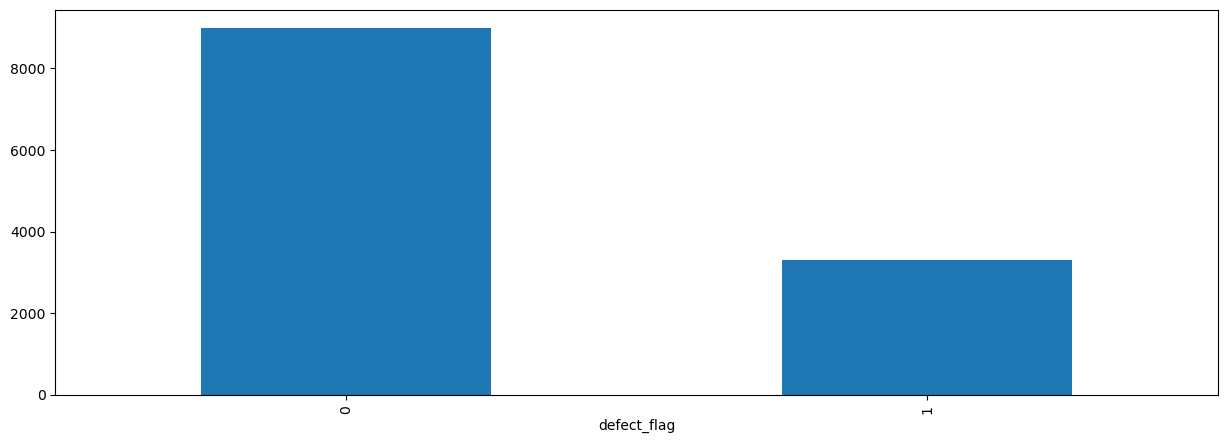

In [20]:
# Checking the distribution of the Target Variable

ApexFinalData.groupby('defect_flag').size().plot(kind='bar',figsize=(15,5))

# The distribution looks satisfactory to proceed

In [21]:
# Classify Columns
# PURPOSE: Separate numerical and categorical columns based on number of unique values

# Creating a 1D-array (Series) of the columns and the corresponding number of unique values
UniqueValues = ApexFinalData.nunique()

CategoricalCols = []
ContinuousCols = []

for col in UniqueValues.index:
    if UniqueValues[col] > 20:
        ContinuousCols.append(col)
    else:
        CategoricalCols.append(col)

print("No. of continuous columns are : ", len(ContinuousCols))
print("No. of categorical columns are : ",len(CategoricalCols))

No. of continuous columns are :  21
No. of categorical columns are :  14


# Visual Data Exploration -

- Categorical : Bar Chart
- Continuous : Histogram

- Bar Charts

In [22]:
# Plotting multiple bar charts at once for categorical variables
# Since there is no default function which can plot bar charts for multiple columns at once
# we are defining our own function for the same

def PlotBarChart(Dataset,colsToPlot):
    
    fig , subPlot = plt.subplots(nrows=1,ncols=len(colsToPlot),figsize=(15,5))
    
    for cols,i in zip(colsToPlot,range(len(colsToPlot))):
        Dataset.groupby(cols).size().plot(kind='bar',ax=subPlot[i])

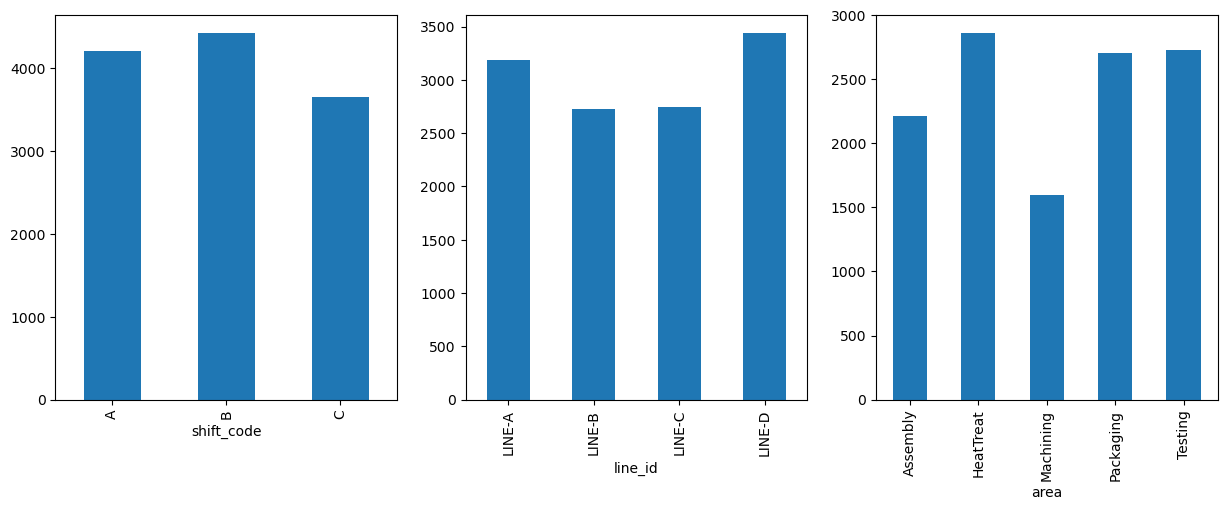

In [23]:
# Calling the function to plot the Bar Charts

CategoricalCols = ['shift_code','line_id','area']

PlotBarChart(Dataset=ApexFinalData,colsToPlot=CategoricalCols)

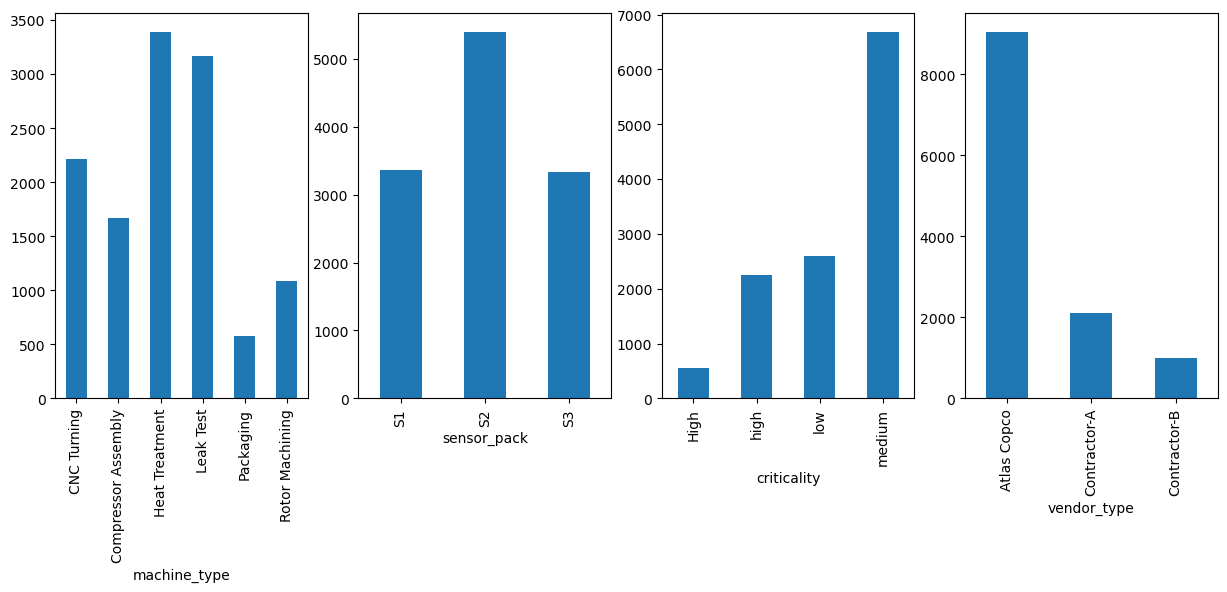

In [24]:
# Calling the function to plot the Bar Charts

CategoricalCols = ['machine_type','sensor_pack','criticality','vendor_type']

PlotBarChart(Dataset=ApexFinalData,colsToPlot=CategoricalCols)

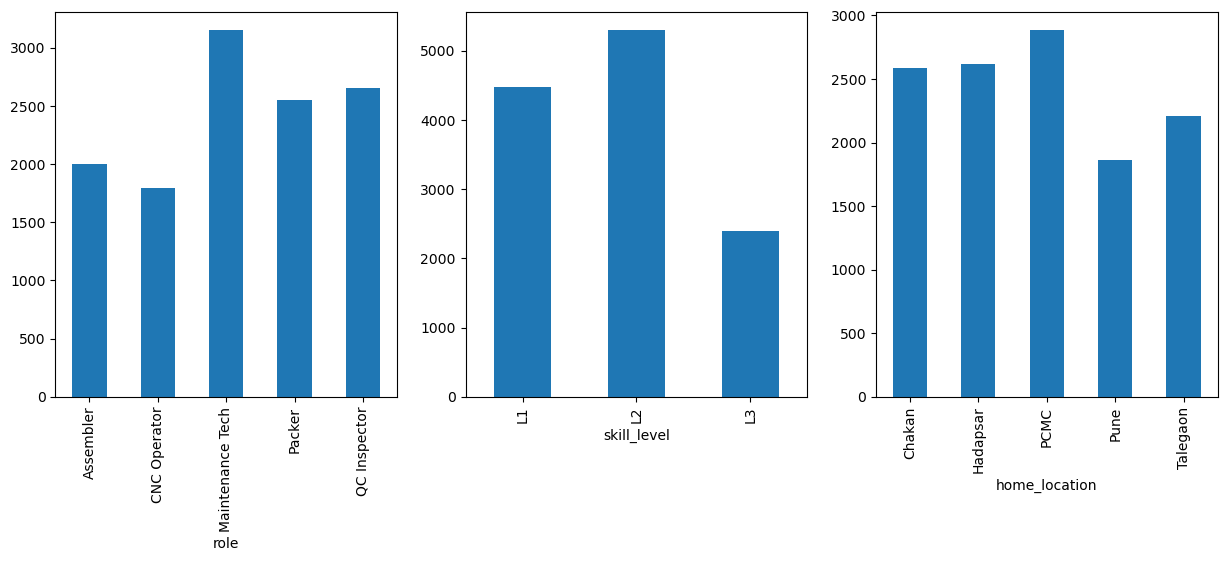

In [25]:
# Calling the function to plot the Bar Charts

CategoricalCols = ['role','skill_level','home_location']

PlotBarChart(Dataset=ApexFinalData,colsToPlot=CategoricalCols)

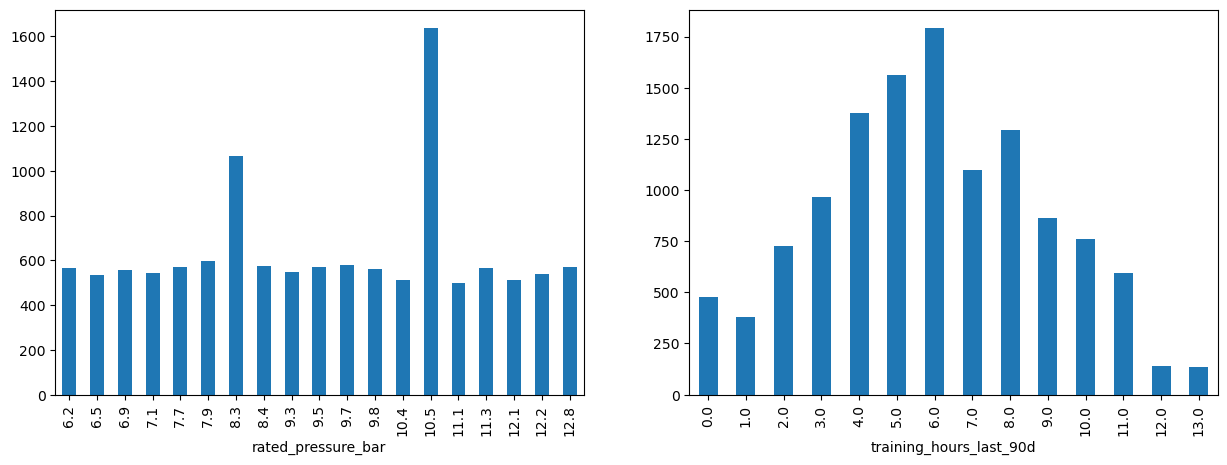

In [26]:
# Calling the function to plot the Bar Charts

CategoricalCols = ['rated_pressure_bar','training_hours_last_90d']
PlotBarChart(Dataset=ApexFinalData,colsToPlot=CategoricalCols)

<Axes: xlabel='product_code'>

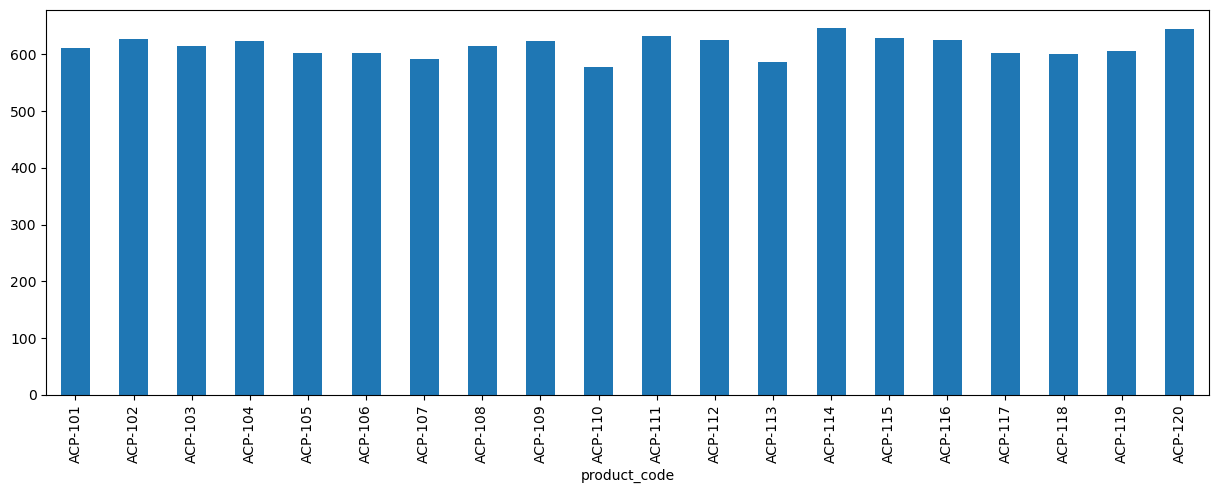

In [27]:
# Plotting product code -
ApexFinalData.groupby('product_code').size().plot(kind='bar',figsize=(15,5))

<Axes: xlabel='machine_id'>

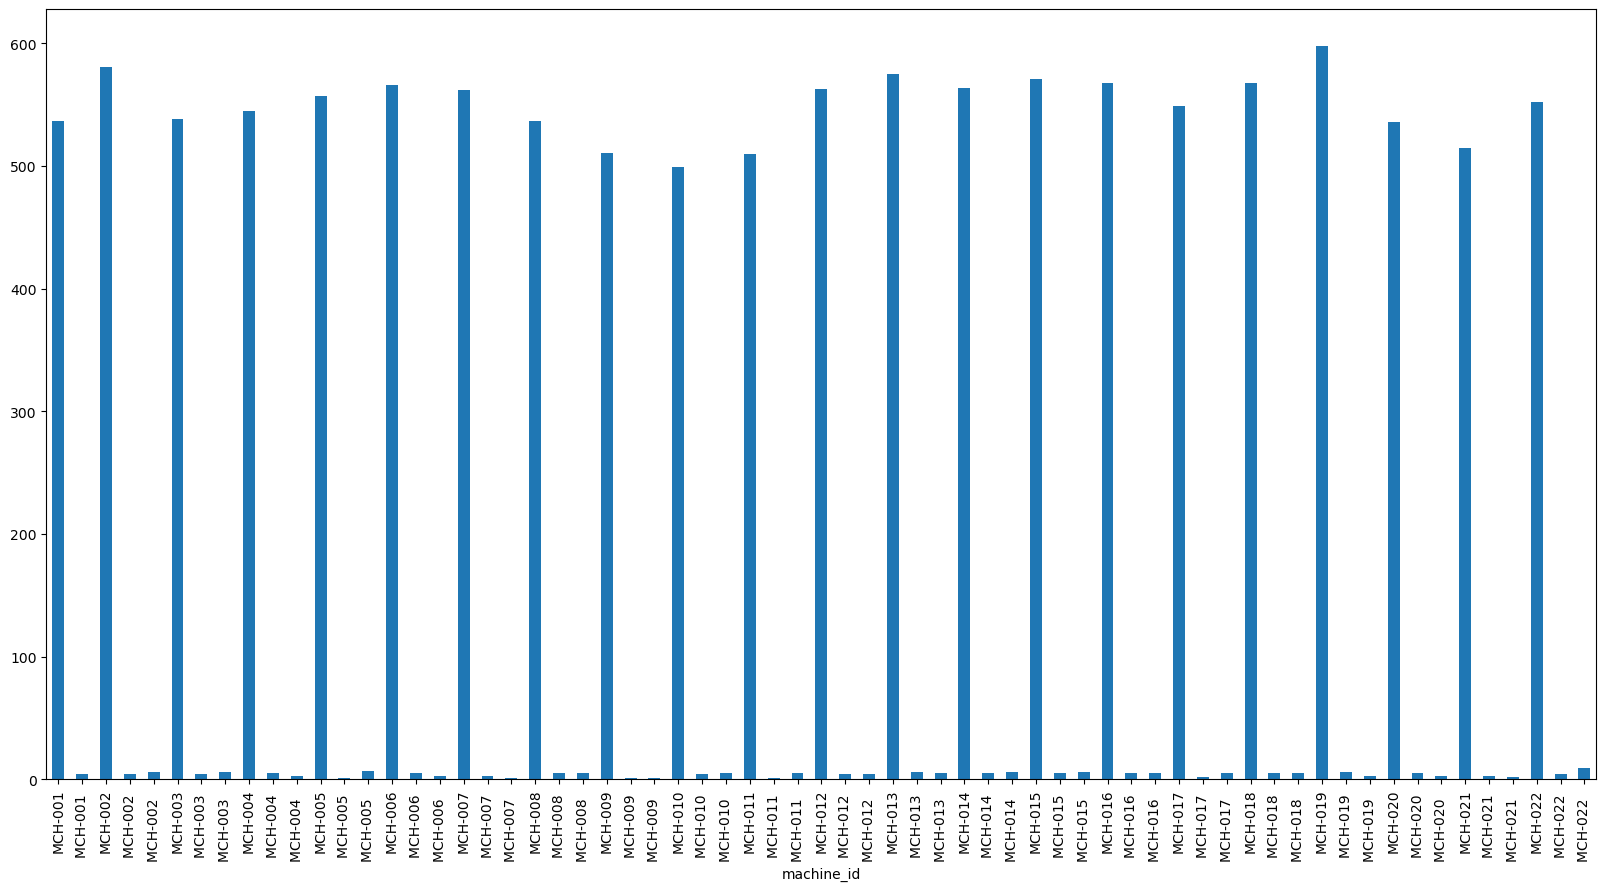

In [28]:
ApexFinalData.groupby('machine_id').size().plot(kind='bar',figsize=(20,10))

# Treating Imbalance in categorical predictors

In [ ]:
# Grouping few columns of into a single bucket where-ever possible

ApexFinalData['vendor_type'].replace({'atlas copco':'Atlas Copco',' Contractor-A':'Contractor-A'},inplace=True)
ApexFinalData['shift_code'].replace({'a':'A','B ':'B','c':'C'},inplace=True)
ApexFinalData['line_id'].replace({' line-b':'LINE-B','LINE-a ':'LINE-A'},inplace=True)
ApexFinalData['skill_level'].replace({'L 1':'L1','l2':'L2','L3 ':'L3'},inplace=True)

- Histograms

array([[<Axes: title={'center': 'planned_units'}>,
        <Axes: title={'center': 'good_units'}>],
       [<Axes: title={'center': 'downtime_min'}>,
        <Axes: title={'center': 'changeover_min'}>],
       [<Axes: title={'center': 'overtime_min'}>,
        <Axes: title={'center': 'speed_rpm'}>]], dtype=object)

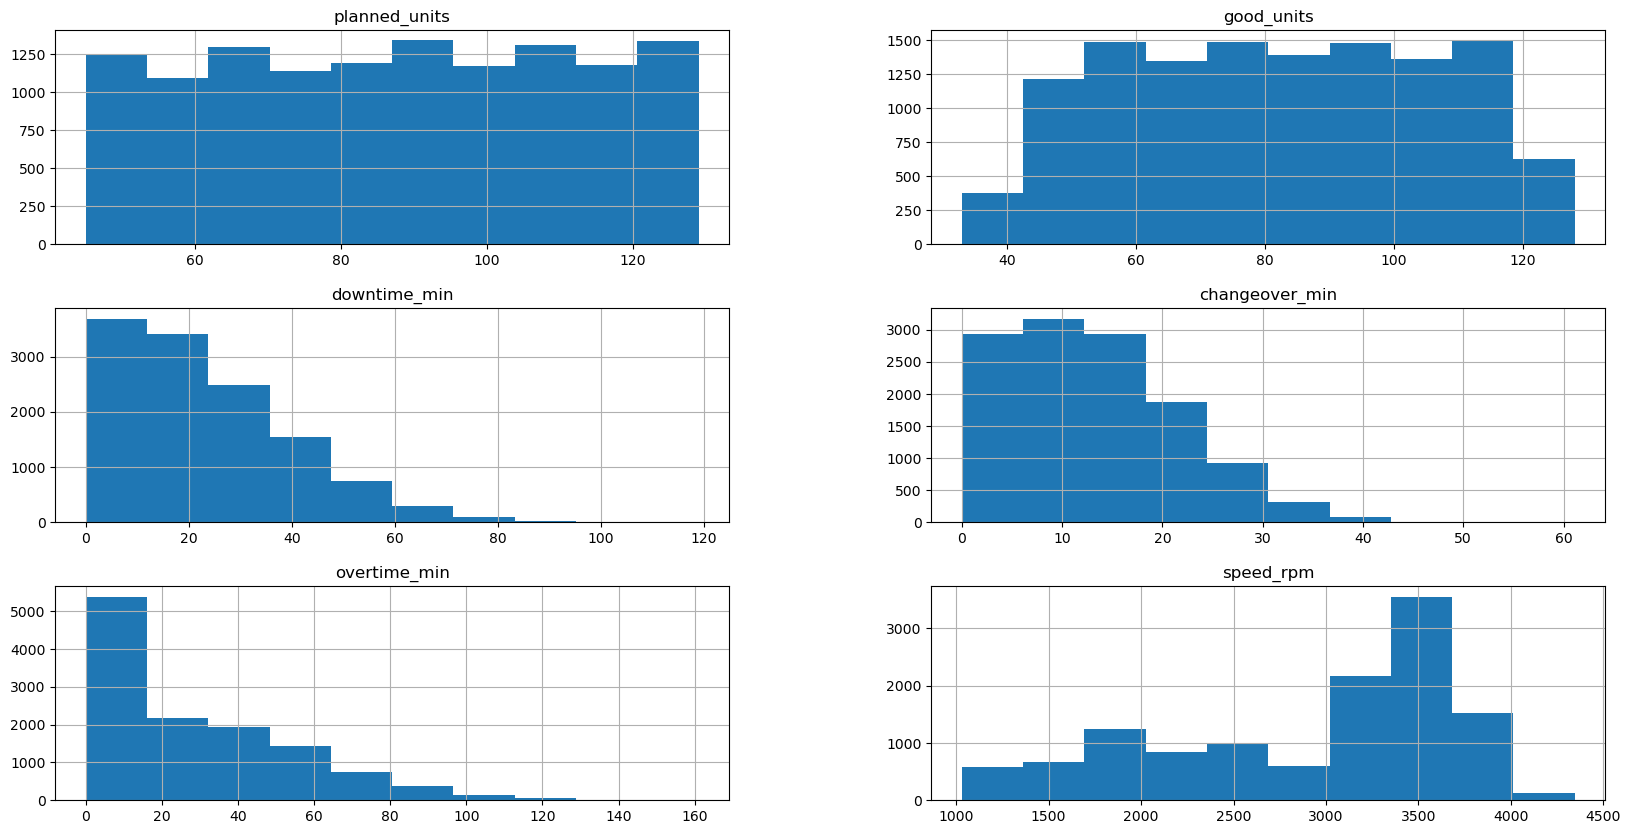

In [29]:
# Plotting histograms of multiple columns together
# Observe the outliers

ApexFinalData.hist(['planned_units','good_units','downtime_min','changeover_min','overtime_min','speed_rpm'],
                   figsize=(20,10))

array([[<Axes: title={'center': 'pressure_bar'}>,
        <Axes: title={'center': 'vibration_mm_s'}>],
       [<Axes: title={'center': 'oil_temp_c'}>,
        <Axes: title={'center': 'torque_nm'}>],
       [<Axes: title={'center': 'ambient_temp_c'}>,
        <Axes: title={'center': 'ambient_humidity_pct'}>]], dtype=object)

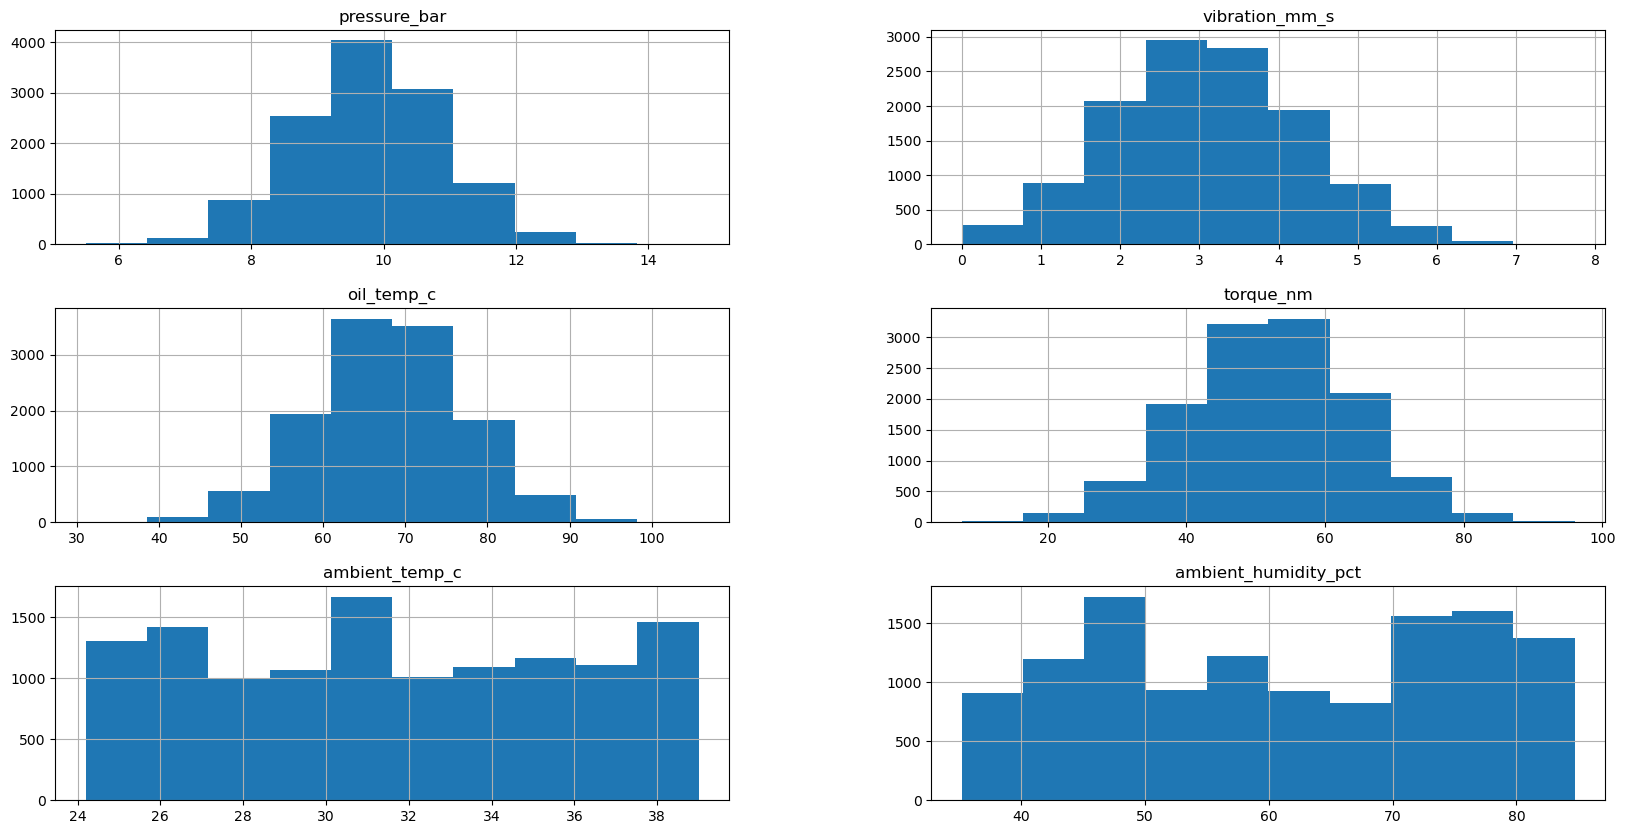

In [30]:
# Plotting histograms of multiple columns together
# Observe the outliers

ApexFinalData.hist(['pressure_bar','vibration_mm_s','oil_temp_c','torque_nm',
 'ambient_temp_c','ambient_humidity_pct'],figsize=(20,10))

array([[<Axes: title={'center': 'actual_cycle_time_sec'}>,
        <Axes: title={'center': 'scrap_pct'}>],
       [<Axes: title={'center': 'rework_min'}>,
        <Axes: title={'center': 'rated_speed_rpm'}>],
       [<Axes: title={'center': 'experience_years'}>,
        <Axes: title={'center': 'ProductionEfficiency'}>]], dtype=object)

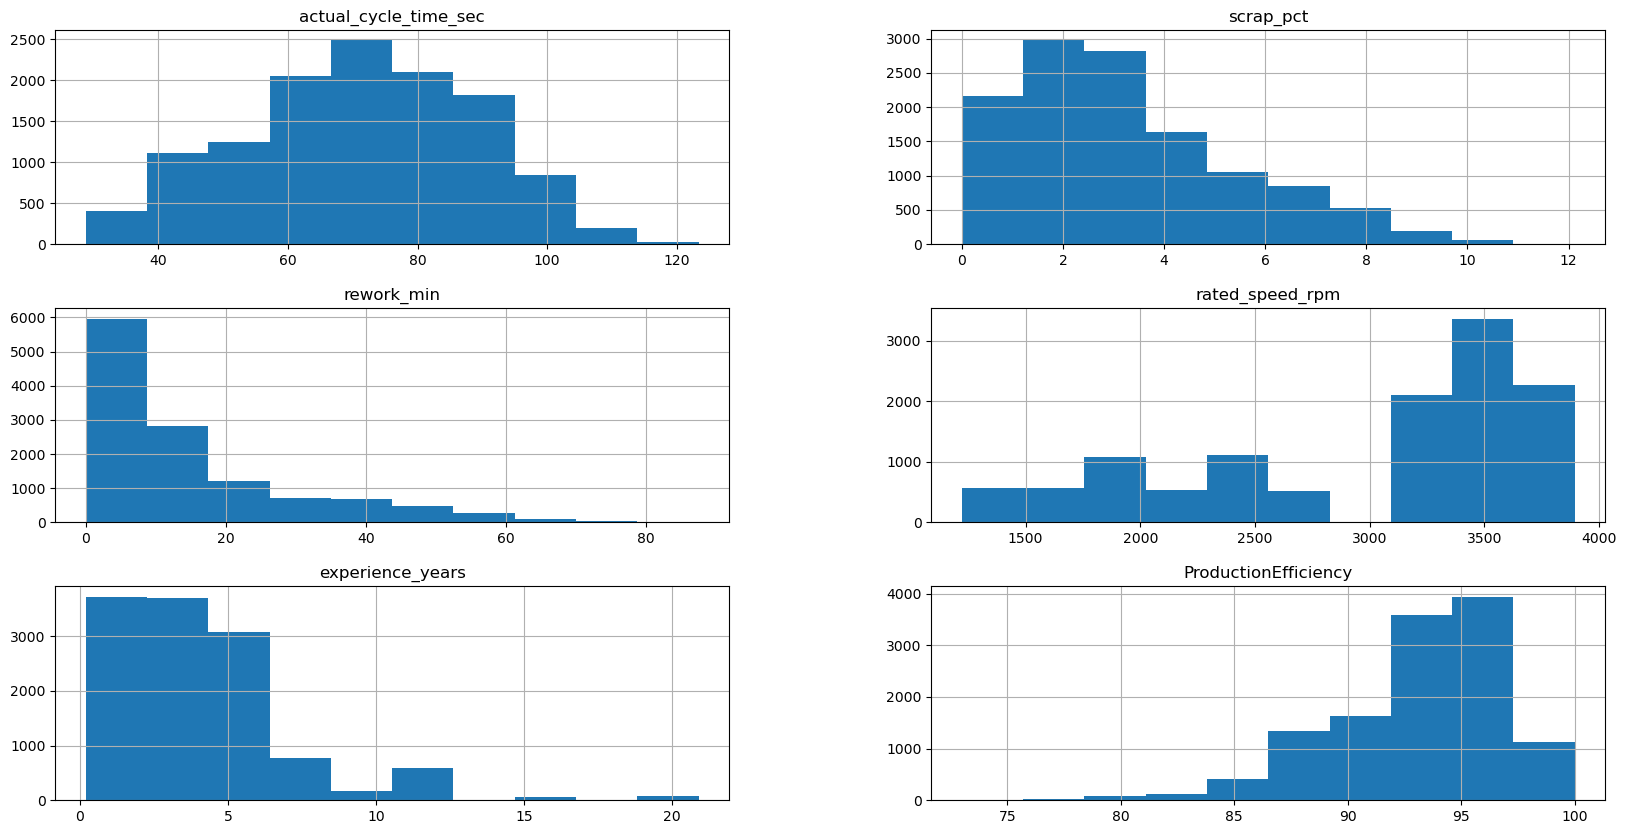

In [31]:
# Plotting histograms of multiple columns together
# Observe the outliers

ApexFinalData.hist(['actual_cycle_time_sec','scrap_pct','rework_min',
 'rated_speed_rpm','experience_years','ProductionEfficiency'],figsize=(20,10))

# Outlier Treatment

Outliers bias the training of machine learning models. As the algorithm tries to fit the extreme value, it goes away from majority of the data.

There are below two options to treat outliers in the data.

Option-1: Delete the outlier Records. Only if there are just few rows lost.

Option-2: Impute the outlier values with a logical business value

Below we are finding out the most logical value to be replaced in place of outliers by looking at the histogram.

In [32]:
Filter = ApexFinalData['downtime_min'] > 95

ApexFinalData['downtime_min'][Filter].sort_values()

1349      95.3
12023     96.3
9675      97.6
10730    104.7
1567     108.0
6552     118.9
Name: downtime_min, dtype: float64

In [33]:
ApexFinalData['downtime_min'][Filter] = 95

In [34]:
Filter = ApexFinalData['overtime_min'] > 130
ApexFinalData['overtime_min'][Filter].sort_values()

3901     131
4682     131
7477     131
11875    131
7497     134
2393     135
6196     137
3667     139
9464     139
9100     142
12225    146
6018     149
8272     149
3296     151
11792    151
7859     161
Name: overtime_min, dtype: int64

In [35]:
ApexFinalData['overtime_min'][Filter] = 130

In [36]:
Filter = ApexFinalData['rework_min'] > 75
ApexFinalData['rework_min'][Filter].sort_values()

9042     75.1
1893     75.6
9842     75.6
4350     75.8
915      75.9
9816     75.9
1993     76.6
4338     78.0
5204     78.1
4812     79.1
7543     79.9
5016     80.1
9845     81.2
6991     81.3
11816    87.5
Name: rework_min, dtype: float64

In [37]:
ApexFinalData['rework_min'][Filter] = 75

In [38]:
Filter = ApexFinalData['ProductionEfficiency'] < 77
ApexFinalData['ProductionEfficiency'][Filter].sort_values()

1349     73.0
2226     73.0
4323     73.0
12032    73.0
3465     74.0
613      76.0
629      76.0
1433     76.0
1689     76.0
6043     76.0
6539     76.0
Name: ProductionEfficiency, dtype: float64

In [39]:
ApexFinalData['ProductionEfficiency'][Filter] = 77

array([[<Axes: title={'center': 'downtime_min'}>,
        <Axes: title={'center': 'overtime_min'}>],
       [<Axes: title={'center': 'rework_min'}>,
        <Axes: title={'center': 'ProductionEfficiency'}>]], dtype=object)

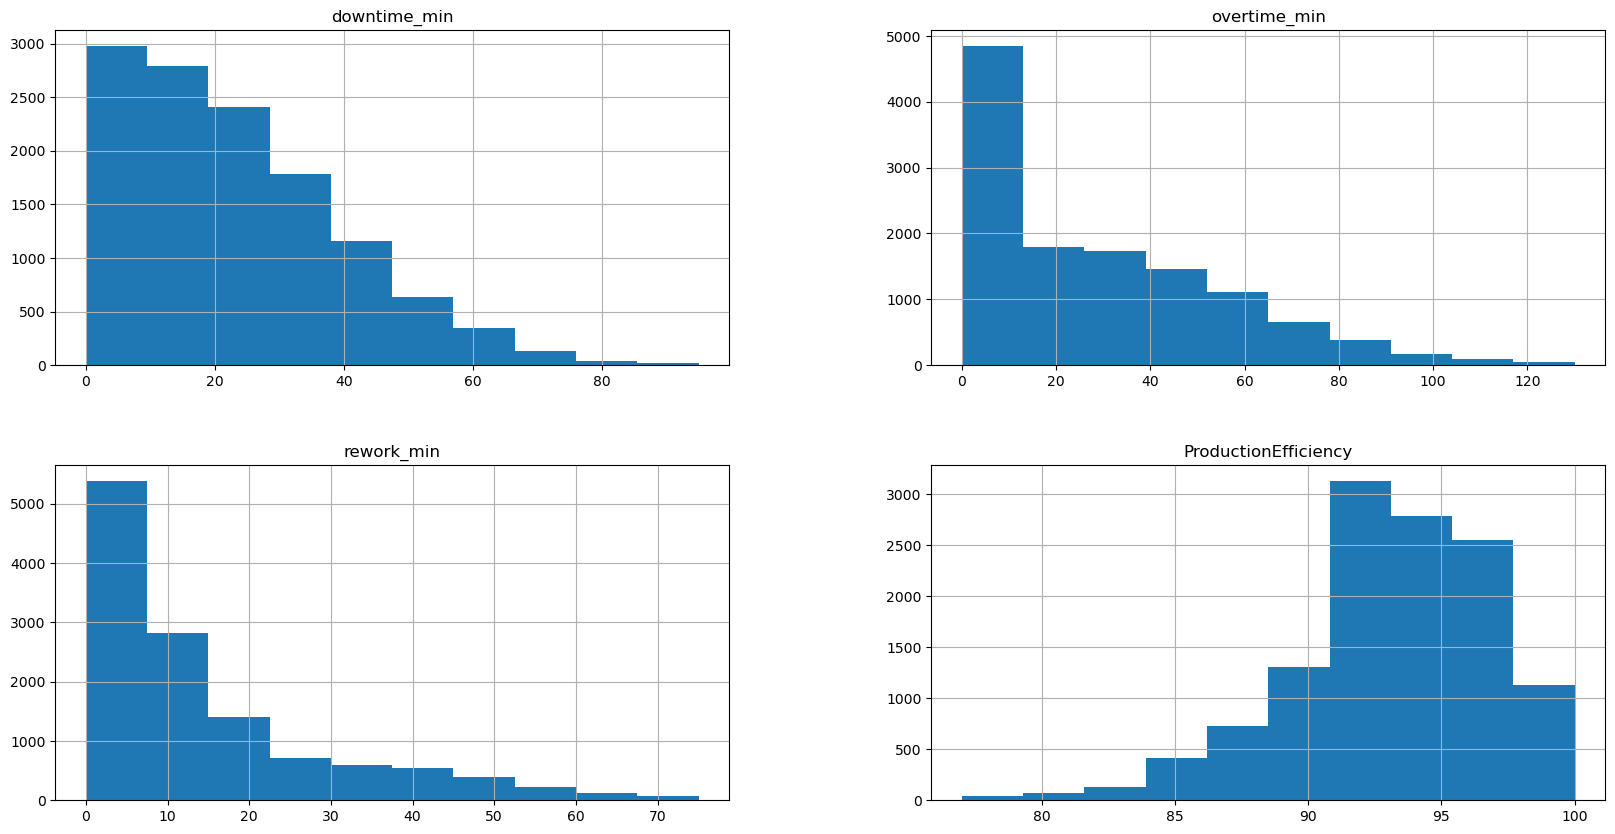

In [40]:
# Visualizing the distribution after Outlier Treatment

ApexFinalData.hist(['downtime_min','overtime_min','rework_min','ProductionEfficiency'],figsize=(20,10))

# Missing Values Treatment

Missing values are treated for each column separately.

If a column has more than 30% data missing, then missing value treatment cannot be done. That column must be
rejected because too much information is missing.

There are below options for treating missing values in data.

- Delete the missing value rows if there are only few records
- Impute the missing values with MEDIAN value for continuous variables
- Impute the missing values with MODE value for categorical variables
- Interpolate the values based on nearby values
- Interpolate the values based on business logic

In [41]:
ApexFinalData.isnull().sum()

shift_code                   0
machine_id                   0
operator_id                122
product_code                 0
batch_id                     0
planned_units                0
good_units                   0
downtime_min                 0
changeover_min               0
overtime_min                 0
speed_rpm                    0
pressure_bar               125
vibration_mm_s             123
oil_temp_c                 154
torque_nm                    0
ambient_temp_c               0
ambient_humidity_pct         0
actual_cycle_time_sec        0
scrap_pct                    0
rework_min                   0
defect_flag                  0
line_id                    182
area                       182
machine_type               182
rated_speed_rpm            182
rated_pressure_bar         182
sensor_pack                182
criticality                182
vendor_type                122
role                       122
skill_level                122
experience_years           122
home_loc

In [42]:
# Finding the % of missing values for each row and dropping the rows having more than 30% missing values

DropCols = []

for cols in ApexFinalData.columns:
    Missing_values = ApexFinalData[cols].isnull().sum()
    Length_of_col = len(ApexFinalData[cols])
    MissingPercentage = round(100*(Missing_values/Length_of_col))
    
    if MissingPercentage>30:
        DropCols.append(cols)
    
        
    
    print(cols, " missing value are : ", MissingPercentage, "%")

shift_code  missing value are :  0 %
machine_id  missing value are :  0 %
operator_id  missing value are :  1 %
product_code  missing value are :  0 %
batch_id  missing value are :  0 %
planned_units  missing value are :  0 %
good_units  missing value are :  0 %
downtime_min  missing value are :  0 %
changeover_min  missing value are :  0 %
overtime_min  missing value are :  0 %
speed_rpm  missing value are :  0 %
pressure_bar  missing value are :  1 %
vibration_mm_s  missing value are :  1 %
oil_temp_c  missing value are :  1 %
torque_nm  missing value are :  0 %
ambient_temp_c  missing value are :  0 %
ambient_humidity_pct  missing value are :  0 %
actual_cycle_time_sec  missing value are :  0 %
scrap_pct  missing value are :  0 %
rework_min  missing value are :  0 %
defect_flag  missing value are :  0 %
line_id  missing value are :  1 %
area  missing value are :  1 %
machine_type  missing value are :  1 %
rated_speed_rpm  missing value are :  1 %
rated_pressure_bar  missing value ar

- Mode imputation for Categorical columns and Median imputation for Continuous columns to treat the missing values

In [43]:
# Replacing missing values of categorical variables with the mode value

ApexFinalData['operator_id'].fillna(ApexFinalData['operator_id'].mode()[0],inplace=True)
ApexFinalData['line_id'].fillna(ApexFinalData['line_id'].mode()[0],inplace=True)
ApexFinalData['area'].fillna(ApexFinalData['area'].mode()[0],inplace=True)
ApexFinalData['machine_type'].fillna(ApexFinalData['machine_type'].mode()[0],inplace=True)
ApexFinalData['rated_pressure_bar'].fillna(ApexFinalData['rated_pressure_bar'].mode()[0],inplace=True)
ApexFinalData['sensor_pack'].fillna(ApexFinalData['sensor_pack'].mode()[0],inplace=True)
ApexFinalData['criticality'].fillna(ApexFinalData['criticality'].mode()[0],inplace=True)
ApexFinalData['vendor_type'].fillna(ApexFinalData['vendor_type'].mode()[0],inplace=True)
ApexFinalData['role'].fillna(ApexFinalData['role'].mode()[0],inplace=True)
ApexFinalData['skill_level'].fillna(ApexFinalData['skill_level'].mode()[0],inplace=True)
ApexFinalData['home_location'].fillna(ApexFinalData['home_location'].mode()[0],inplace=True)
ApexFinalData['training_hours_last_90d'].fillna(ApexFinalData['training_hours_last_90d'].mode()[0],inplace=True)


# Replacing missing values of continuous variables with the median value

ApexFinalData['pressure_bar'].fillna(ApexFinalData['pressure_bar'].median(),inplace=True)
ApexFinalData['vibration_mm_s'].fillna(ApexFinalData['vibration_mm_s'].median(),inplace=True)
ApexFinalData['oil_temp_c'].fillna(ApexFinalData['oil_temp_c'].median(),inplace=True)
ApexFinalData['rated_speed_rpm'].fillna(ApexFinalData['rated_speed_rpm'].median(),inplace=True)
ApexFinalData['rated_pressure_bar'].fillna(ApexFinalData['rated_pressure_bar'].median(),inplace=True)
ApexFinalData['experience_years'].fillna(ApexFinalData['experience_years'].median(),inplace=True)





In [44]:
# Checking the missing values after treatment
ApexFinalData.isnull().sum()

shift_code                 0
machine_id                 0
operator_id                0
product_code               0
batch_id                   0
planned_units              0
good_units                 0
downtime_min               0
changeover_min             0
overtime_min               0
speed_rpm                  0
pressure_bar               0
vibration_mm_s             0
oil_temp_c                 0
torque_nm                  0
ambient_temp_c             0
ambient_humidity_pct       0
actual_cycle_time_sec      0
scrap_pct                  0
rework_min                 0
defect_flag                0
line_id                    0
area                       0
machine_type               0
rated_speed_rpm            0
rated_pressure_bar         0
sensor_pack                0
criticality                0
vendor_type                0
role                       0
skill_level                0
experience_years           0
home_location              0
training_hours_last_90d    0
ProductionEffi

# Feature Selection
Visual exploration of relationship between variables
- Continuous Vs Continuous ---- Scatter Plot / Correlation
- Categorical Vs Continuous---- Box Plot / Anova Test
- Categorical Vs Categorical---- Grouped Bar Plots / Chi2 Test

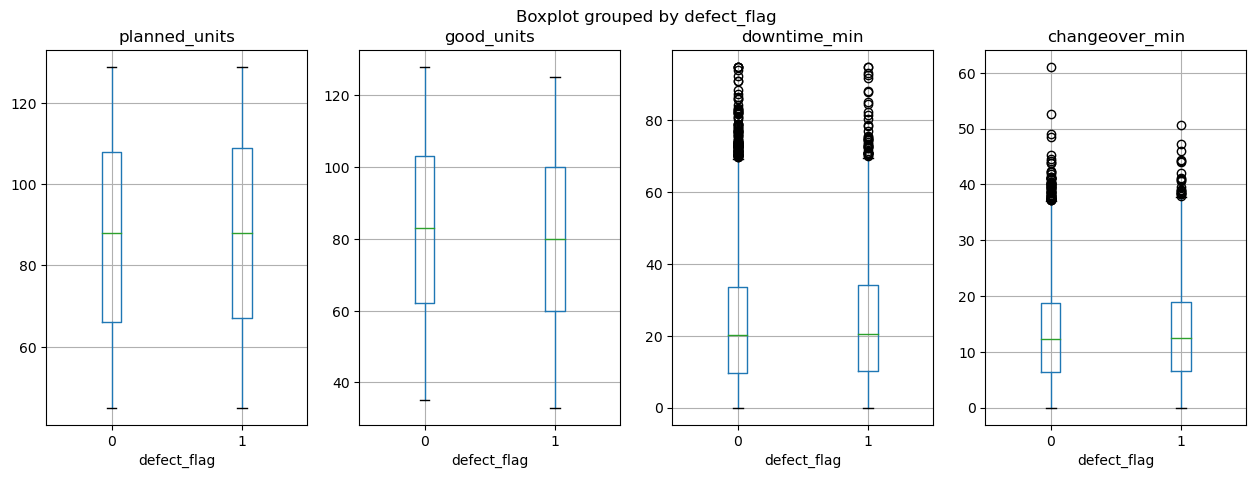

In [45]:
# Categorical Vs Continuous---- Box Plot / Anova Test

TargetVariable = ['defect_flag']
ContinuousPredictors = ['planned_units','good_units','downtime_min','changeover_min']

fig, subPlot = plt.subplots(nrows=1,ncols=len(ContinuousPredictors),figsize=(15,5))

for cols, i in zip(ContinuousPredictors,range(len(ContinuousPredictors))):
    ApexFinalData.boxplot(column=cols,by='defect_flag',ax=subPlot[i])
    

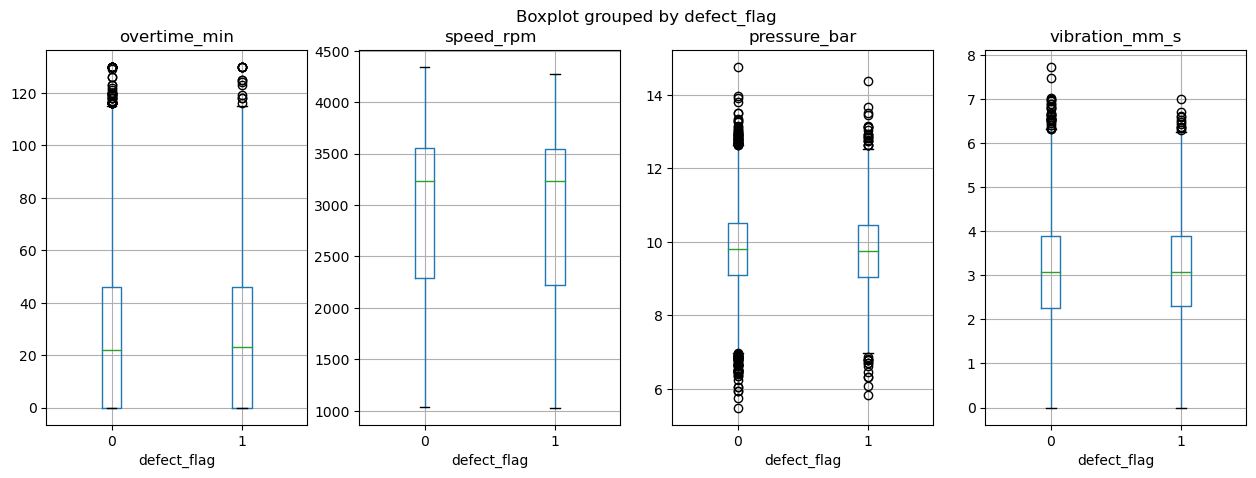

In [46]:
TargetVariable = ['defect_flag']
ContinuousPredictors = ['overtime_min','speed_rpm','pressure_bar','vibration_mm_s']

fig , subPlot = plt.subplots(nrows=1,ncols=len(ContinuousPredictors),figsize=(15,5))

for cols, i in zip(ContinuousPredictors,range(len(ContinuousPredictors))):
    ApexFinalData.boxplot(column=cols,by='defect_flag',ax=subPlot[i])

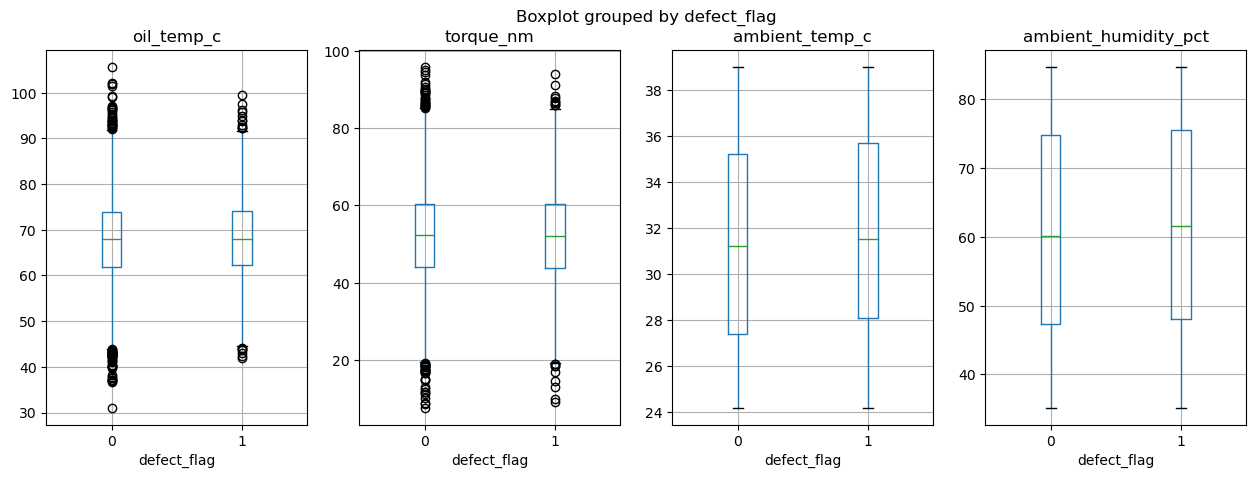

In [47]:
TargetVariable = ['defect_flag']
ContinuousPredictors = ['oil_temp_c','torque_nm','ambient_temp_c','ambient_humidity_pct']

fig, subPlot = plt.subplots(nrows=1,ncols=len(ContinuousPredictors),figsize=(15,5))

for cols, i in zip(ContinuousPredictors,range(len(ContinuousPredictors))):
    ApexFinalData.boxplot(column=cols,by='defect_flag',ax=subPlot[i])

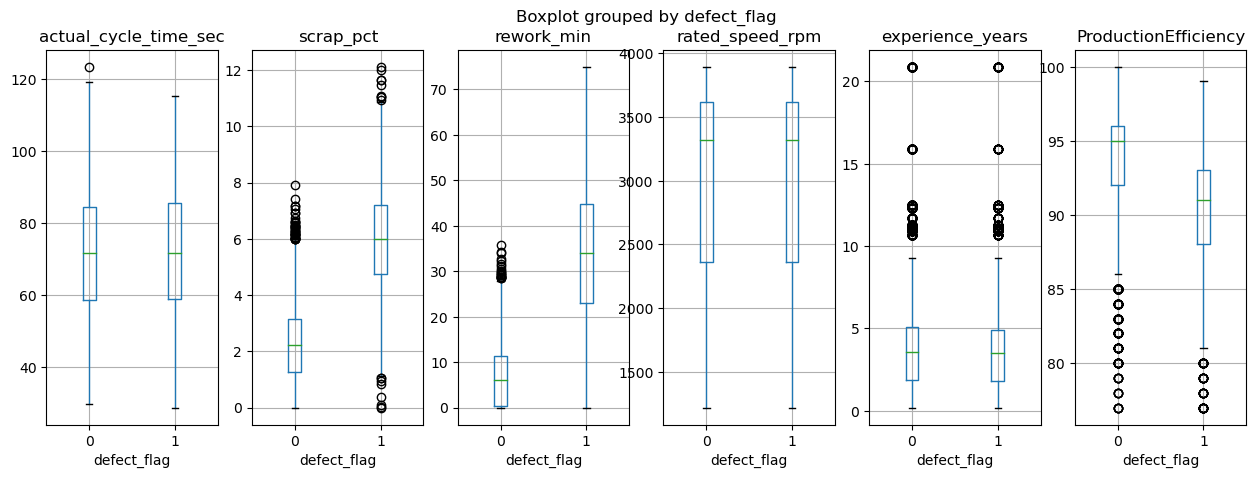

In [48]:
TargetVariable = ['defect_flag']
ContinuousPredictors = ['actual_cycle_time_sec','scrap_pct','rework_min','rated_speed_rpm','experience_years',
                        'ProductionEfficiency']

fig, subPlot = plt.subplots(nrows=1,ncols=len(ContinuousPredictors),figsize=(15,5))
   
for cols, i in zip(ContinuousPredictors,range(len(ContinuousPredictors))):
    ApexFinalData.boxplot(column=cols,by='defect_flag',ax=subPlot[i])

## Anova Test

Analysis of variance(ANOVA) is performed to check if there is any relationship between the given continuous and categorical variable

Assumption(H0): There is NO relation between the given variables (i.e. The average(mean) values of the numeric Predictor variable is same for all the groups in the categorical Target variable)

ANOVA Test result: Probability of H0 being true

In [49]:
# Defining a function to find the statistical relationship with all the categorical variables

def functionAnnova(Dataset,TargetVariable,Predictors):
    from scipy.stats import f_oneway
    
    # Creating an empty list of final selected predictors
    SelectedPredictors = []
    
    for cols in Predictors:
        CategoryList = Dataset.groupby(TargetVariable)[cols].apply(list)
        AnnovaResult = f_oneway(*CategoryList)
        
        if AnnovaResult[1]<0.05:
            print(cols, "is correlated with : ", TargetVariable, " | P-value is : ", AnnovaResult[1])
            SelectedPredictors.append(cols)
        else:
            print(cols, "is NOT correlated with : ", TargetVariable, " | P-value is : ", AnnovaResult[1])
    return(SelectedPredictors)        

In [50]:
# Calling the function to check which continuous variables are correlated with target

ContinuousPredictors = ['planned_units','good_units','downtime_min','changeover_min','overtime_min',
                        'speed_rpm','pressure_bar','vibration_mm_s','oil_temp_c','torque_nm',
                        'ambient_temp_c','ambient_humidity_pct','actual_cycle_time_sec','scrap_pct',
                        'rework_min','rated_speed_rpm','experience_years','ProductionEfficiency']

functionAnnova(Dataset=ApexFinalData,TargetVariable='defect_flag',Predictors=ContinuousPredictors)

planned_units is NOT correlated with :  defect_flag  | P-value is :  0.30013211642562715
good_units is correlated with :  defect_flag  | P-value is :  5.4461025465830575e-09
downtime_min is NOT correlated with :  defect_flag  | P-value is :  0.23654660840927302
changeover_min is NOT correlated with :  defect_flag  | P-value is :  0.05286279456338891
overtime_min is NOT correlated with :  defect_flag  | P-value is :  0.7692707299130987
speed_rpm is NOT correlated with :  defect_flag  | P-value is :  0.21052130004071704
pressure_bar is correlated with :  defect_flag  | P-value is :  0.03885295481940166
vibration_mm_s is NOT correlated with :  defect_flag  | P-value is :  0.6369161765315738
oil_temp_c is correlated with :  defect_flag  | P-value is :  0.016738576389253888
torque_nm is NOT correlated with :  defect_flag  | P-value is :  0.6761260500765229
ambient_temp_c is correlated with :  defect_flag  | P-value is :  0.0007004248270483587
ambient_humidity_pct is correlated with :  defec

['good_units',
 'pressure_bar',
 'oil_temp_c',
 'ambient_temp_c',
 'ambient_humidity_pct',
 'scrap_pct',
 'rework_min',
 'ProductionEfficiency']

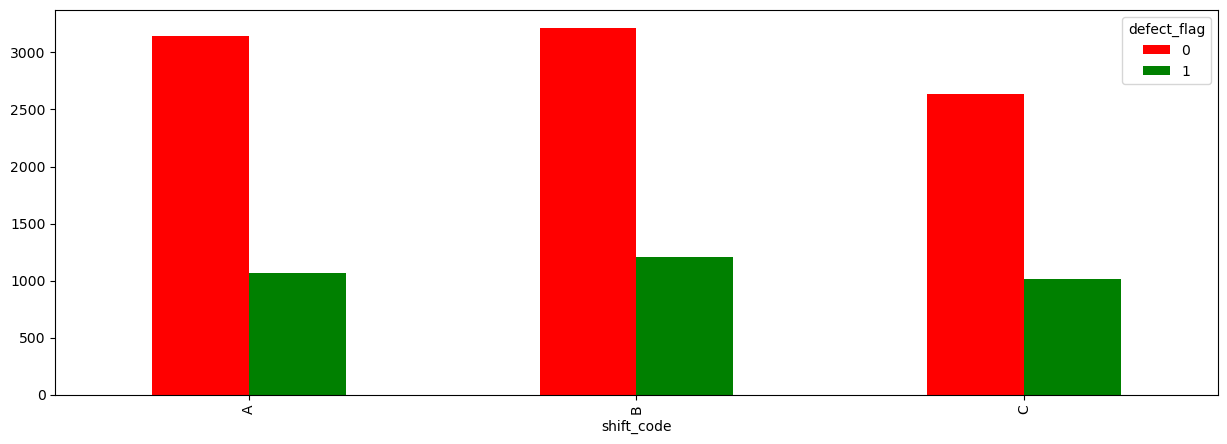

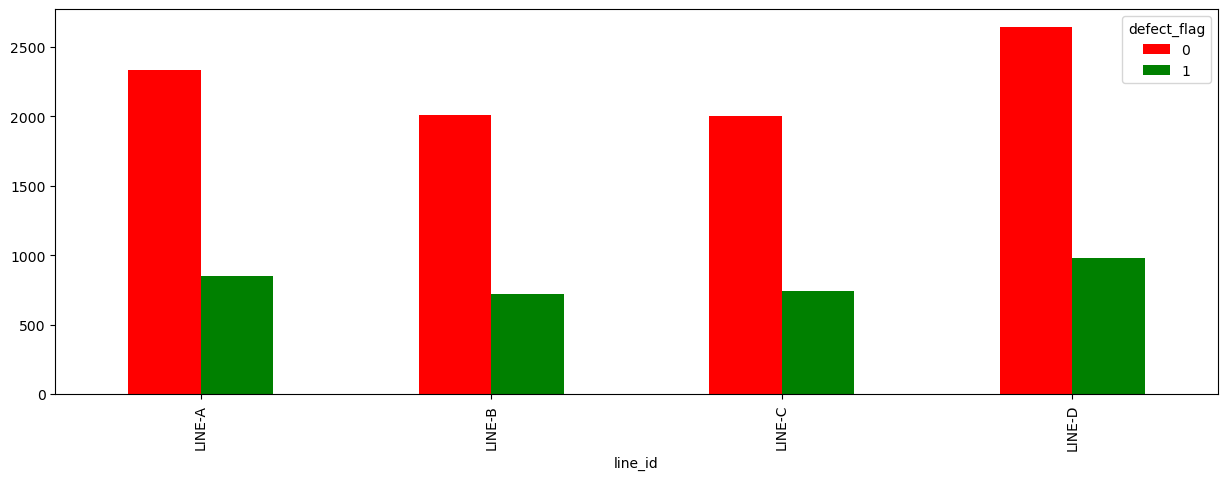

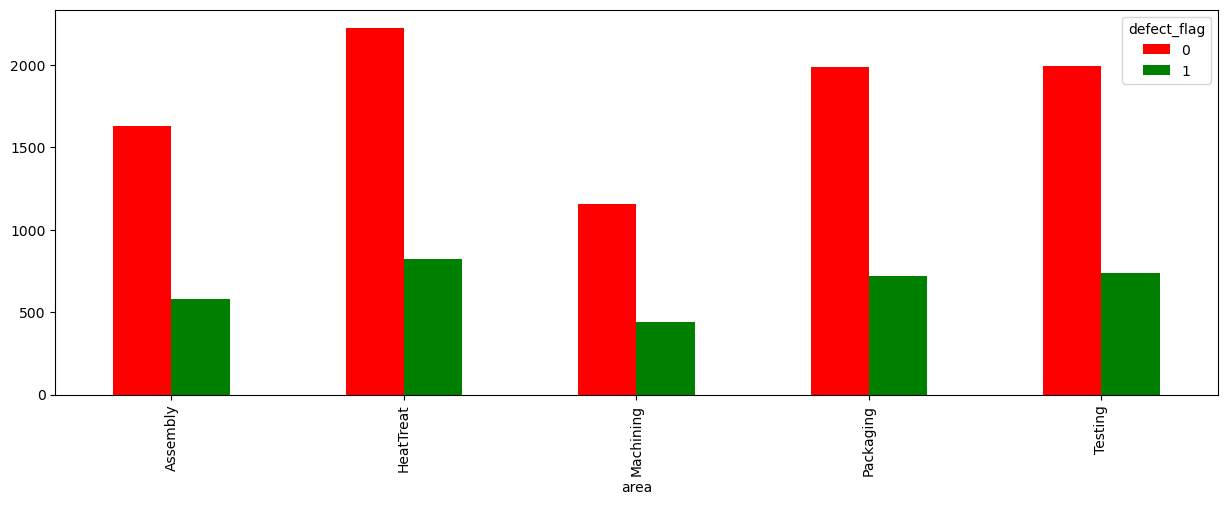

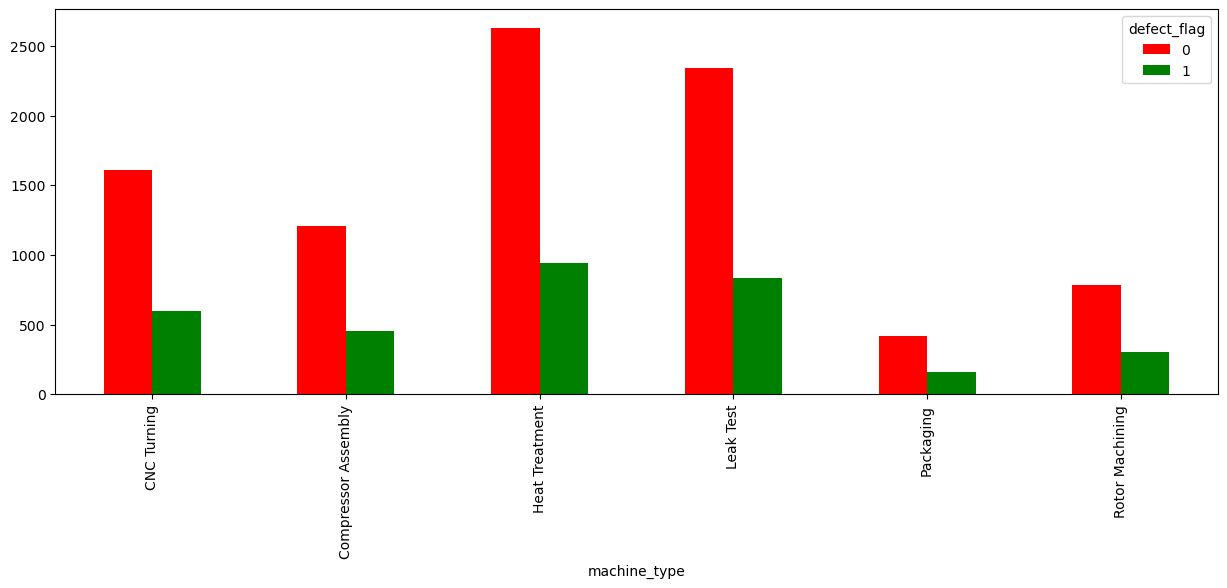

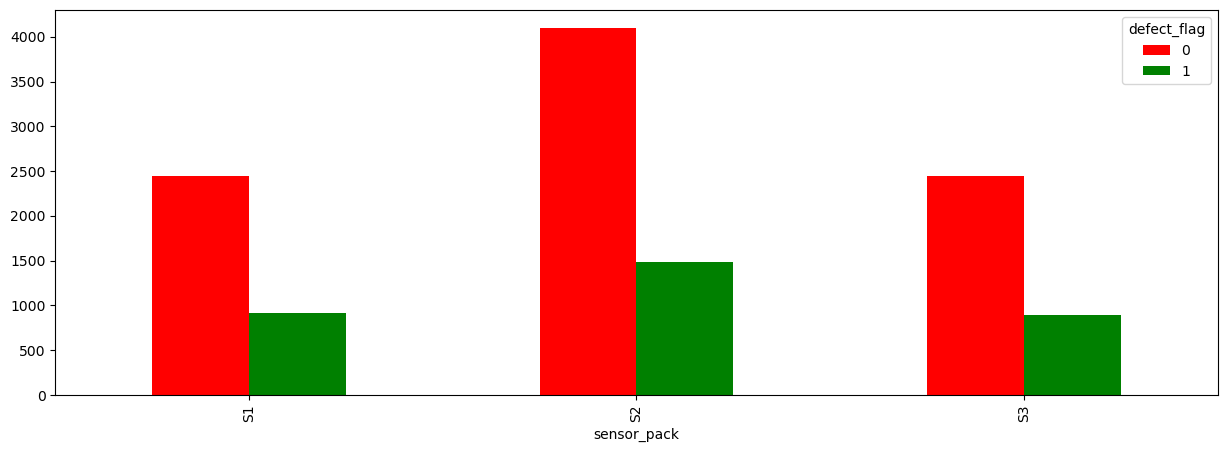

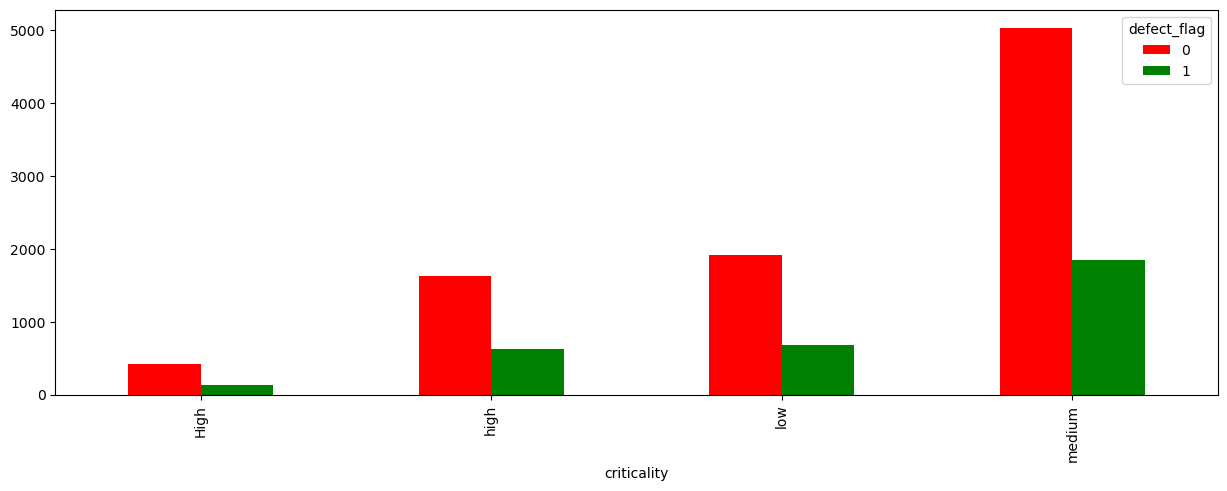

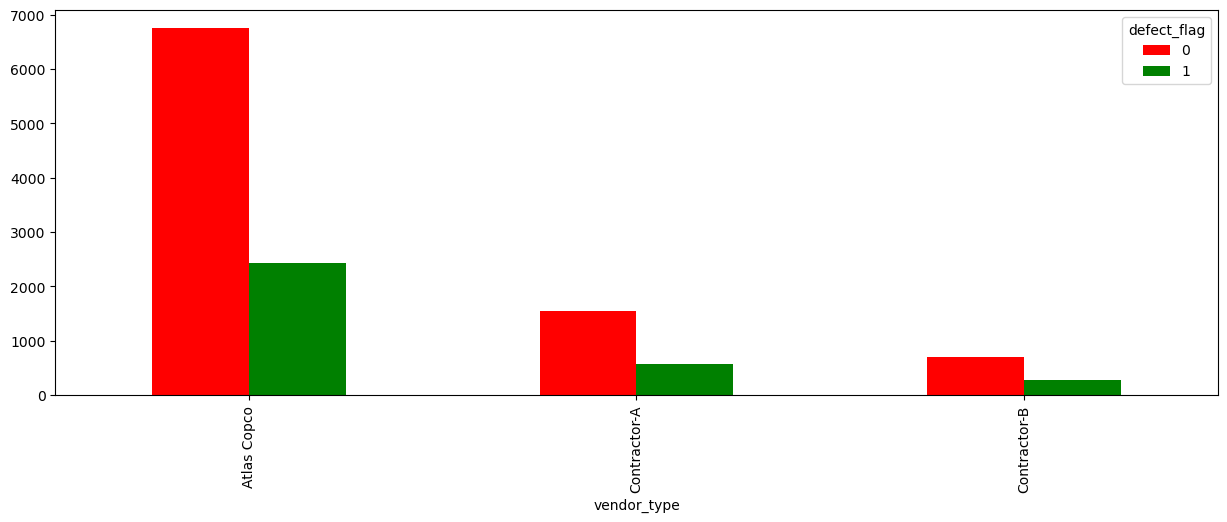

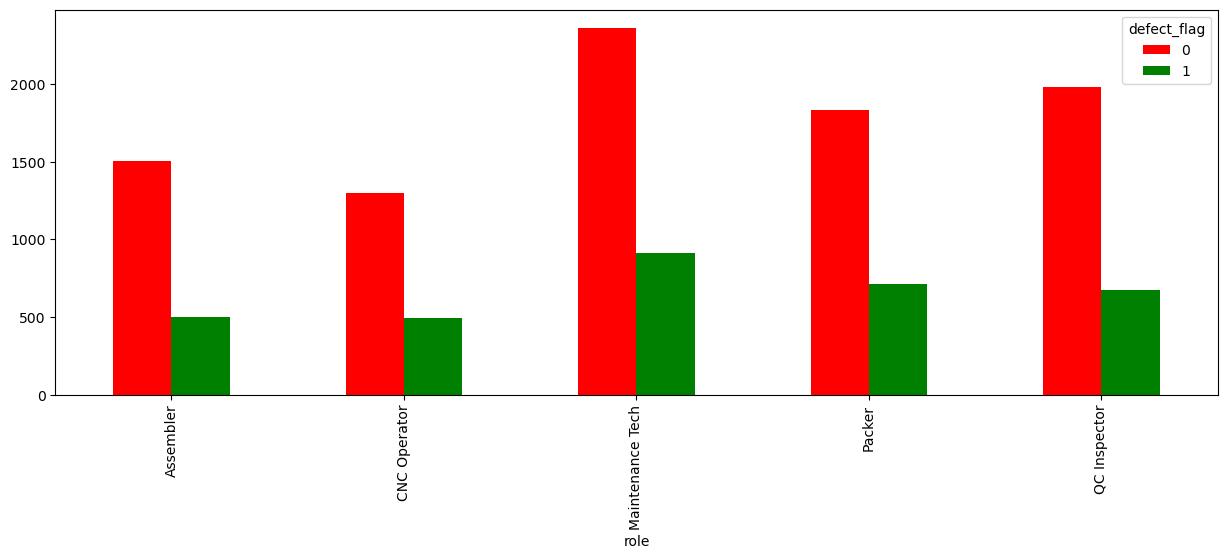

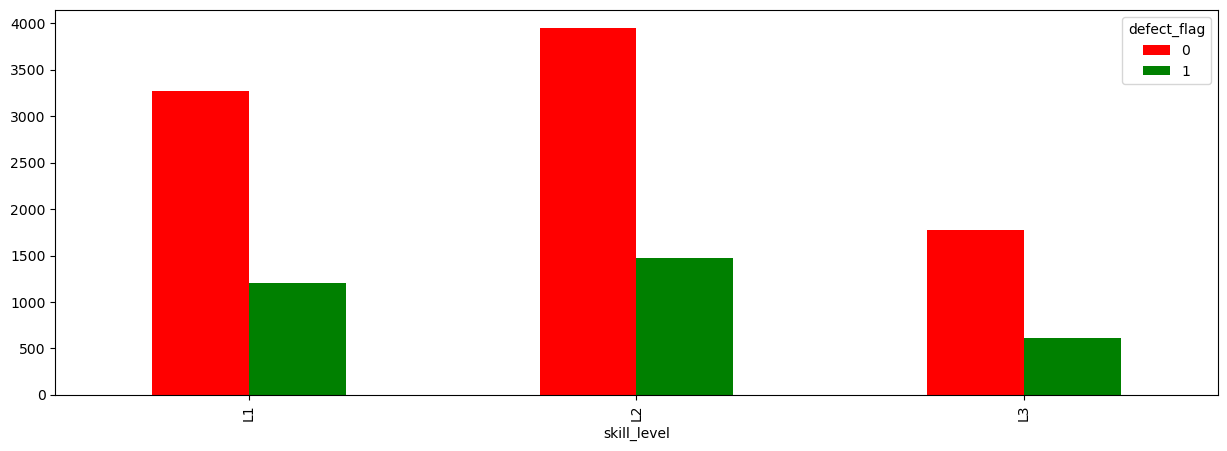

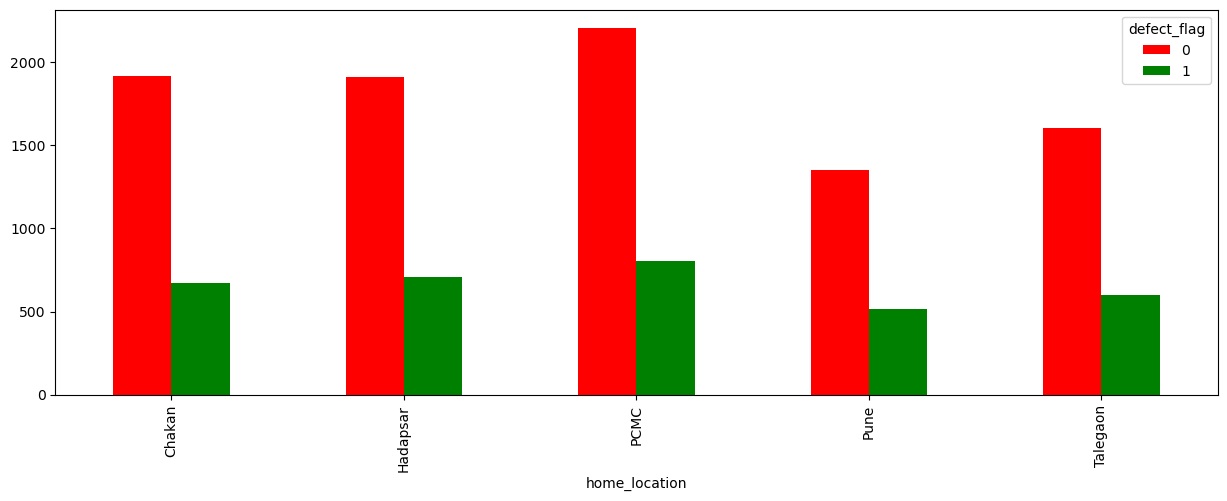

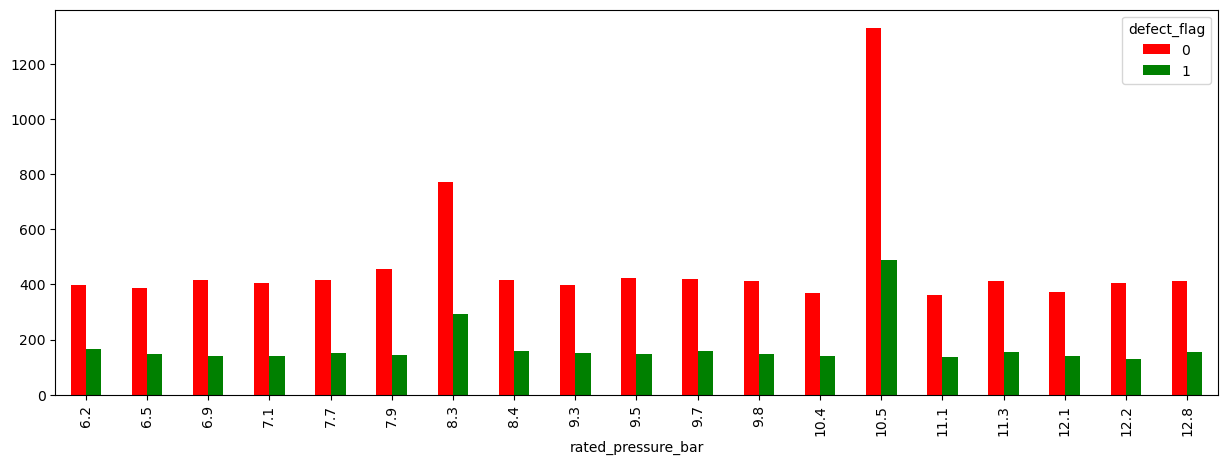

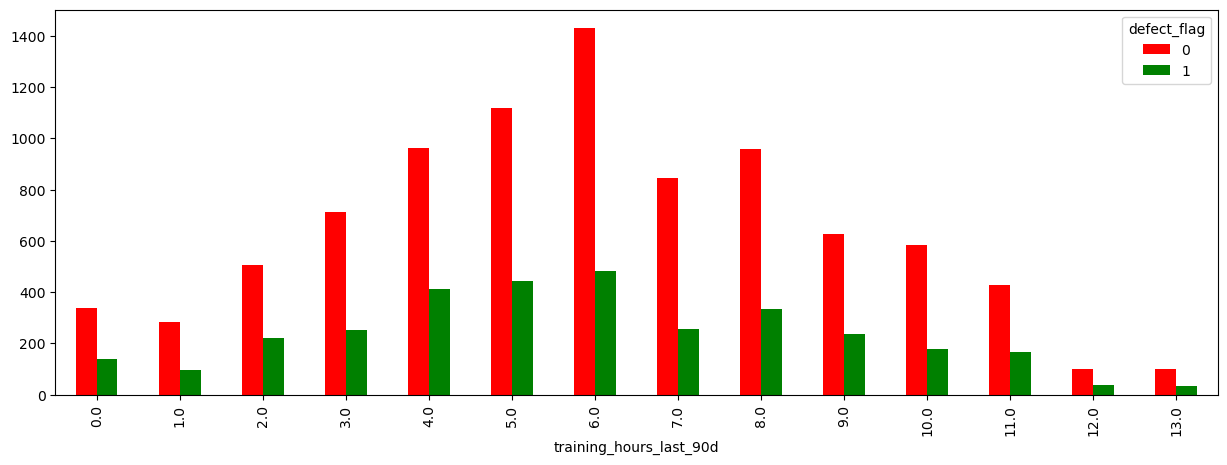

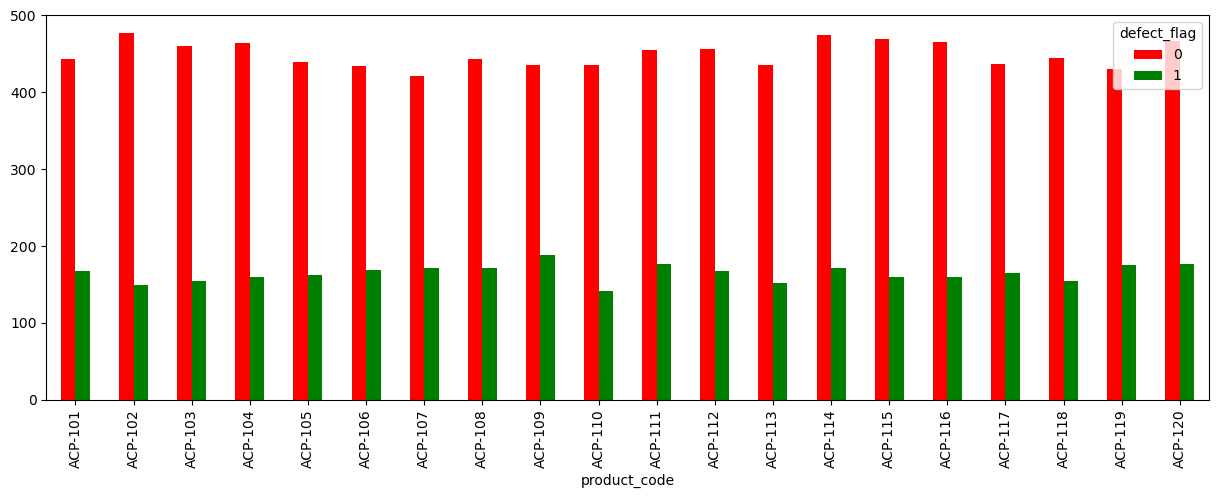

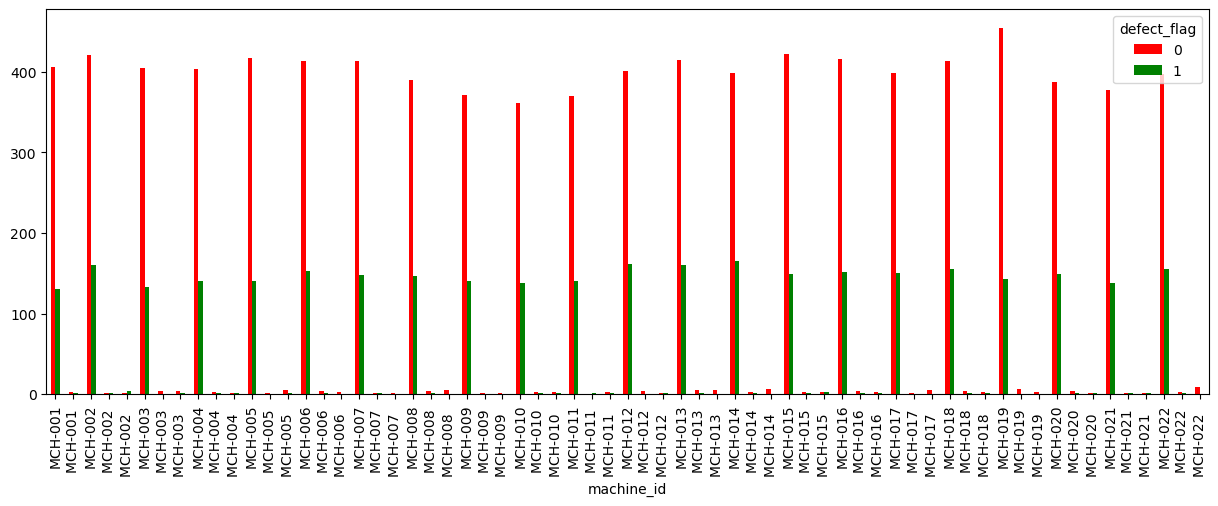

In [51]:
# Categorical Vs Categorical---- Grouped BarChart / Chi2 Test
# Cross tablulation between two categorical variables
# Visual Inference using Grouped Bar charts

TargetVariable = ['defect_flag']
CategoricalCols = ['shift_code','line_id','area','machine_type','sensor_pack','criticality','vendor_type',
                  'role','skill_level','home_location','rated_pressure_bar','training_hours_last_90d',
                  'product_code','machine_id']

for cols in CategoricalCols:
    CrossTabResult = pd.crosstab(ApexFinalData[cols],ApexFinalData['defect_flag'])
    CrossTabResult.plot(kind='bar',color=('red','green'),figsize=(15,5))

# Chi2 Test

Chi-Square test is conducted to check the correlation between two categorical variables

Assumption(H0): The two columns are NOT related to each other

Result of Chi-Sq Test: The Probability of H0 being True

In [52]:
# Writing a function to find the correlation of all categorical variables with the Target variable

def functionChi2(Dataset,TargetVariable,Predictors):
    from scipy.stats import chi2_contingency
    
    # Creating an empty list of final selected predictors
    SelectedPredictors = []
    
    for cols in Predictors:
        CrossTabResult = pd.crosstab(Dataset[cols],Dataset[TargetVariable])
        Chi2_Result = chi2_contingency(CrossTabResult)
        
        # If the Chi2 P-Value is <0.05, that means we reject H0
        if Chi2_Result[1]<0.05:
            print(cols, "is correlated with : ", TargetVariable, " | P-value is : ", Chi2_Result[1])
            SelectedPredictors.append(cols)
        else:
             print(cols, "is NOT correlated with : ", TargetVariable, " | P-value is : ", Chi2_Result[1])
       
    return(SelectedPredictors)

In [53]:
CategoricalCols = ['shift_code','line_id','area','machine_type','sensor_pack','criticality','vendor_type',
                  'role','skill_level','home_location','rated_pressure_bar','training_hours_last_90d',
                  'product_code','machine_id']

# Calling the function
functionChi2(Dataset=ApexFinalData,TargetVariable='defect_flag',Predictors=CategoricalCols)

shift_code is correlated with :  defect_flag  | P-value is :  0.028958769765932067
line_id is NOT correlated with :  defect_flag  | P-value is :  0.8994765763550581
area is NOT correlated with :  defect_flag  | P-value is :  0.8712958661619421
machine_type is NOT correlated with :  defect_flag  | P-value is :  0.8232370572989132
sensor_pack is NOT correlated with :  defect_flag  | P-value is :  0.8297498528834402
criticality is NOT correlated with :  defect_flag  | P-value is :  0.45386843305393487
vendor_type is NOT correlated with :  defect_flag  | P-value is :  0.22349657389266495
role is correlated with :  defect_flag  | P-value is :  0.02946239283803557
skill_level is NOT correlated with :  defect_flag  | P-value is :  0.3338204807424485
home_location is NOT correlated with :  defect_flag  | P-value is :  0.7833240791258615
rated_pressure_bar is NOT correlated with :  defect_flag  | P-value is :  0.9680366767844748
training_hours_last_90d is correlated with :  defect_flag  | P-val

['shift_code', 'role', 'training_hours_last_90d']

# Selecting final predictors for Machine Learning 
Based on the above tests, selecting the final columns for machine learning

['shift_code', 'role','good_units','pressure_bar','oil_temp_c','ambient_temp_c','ambient_humidity_pct',
'scrap_pct','rework_min','ProductionEfficiency','training_hours_last_90d']

In [54]:
SelectedColsForML = ['shift_code', 'role', 'training_hours_last_90d','good_units', 'pressure_bar',
                     'oil_temp_c','ambient_temp_c','ambient_humidity_pct', 'scrap_pct','rework_min',
                     'ProductionEfficiency']

# Selecting final columns
ApexFinalDataForML = ApexFinalData[SelectedColsForML]
ApexFinalDataForML.head(5)

,shift_code,role,training_hours_last_90d,good_units,pressure_bar,oil_temp_c,ambient_temp_c,ambient_humidity_pct,scrap_pct,rework_min,ProductionEfficiency
0,C,Maintenance Tech,11.0,96,10.63,54.0,35.6,81.9,4.99,35.3,94.0
1,A,Assembler,7.0,82,10.66,53.0,38.9,75.6,3.17,7.9,95.0
2,A,QC Inspector,6.0,100,10.59,60.8,36.8,54.1,1.87,0.0,95.0
3,A,Assembler,8.0,47,10.53,67.6,26.5,40.9,4.34,0.0,92.0
4,A,Packer,11.0,79,10.39,78.4,25.9,55.5,0.73,0.0,96.0


In [55]:
# Saving this final data for reference during deployment

ApexFinalDataForML.to_pickle('ApexFinalDataForML.pkl')

# Data Pre-processing for Machine Learning

In [56]:
ApexFinalDataForML['shift_code'].unique()

array(['C', 'A', 'B'], dtype=object)

In [57]:
ApexFinalDataForML['shift_code'].replace({"A":1,"B":2,"C":3},inplace=True)

In [58]:
ApexFinalDataForML.head(5)

,shift_code,role,training_hours_last_90d,good_units,pressure_bar,oil_temp_c,ambient_temp_c,ambient_humidity_pct,scrap_pct,rework_min,ProductionEfficiency
0,3,Maintenance Tech,11.0,96,10.63,54.0,35.6,81.9,4.99,35.3,94.0
1,1,Assembler,7.0,82,10.66,53.0,38.9,75.6,3.17,7.9,95.0
2,1,QC Inspector,6.0,100,10.59,60.8,36.8,54.1,1.87,0.0,95.0
3,1,Assembler,8.0,47,10.53,67.6,26.5,40.9,4.34,0.0,92.0
4,1,Packer,11.0,79,10.39,78.4,25.9,55.5,0.73,0.0,96.0


In [59]:
ApexFinalDataForMLNumeric = pd.get_dummies(ApexFinalDataForML)

In [60]:
ApexFinalDataForMLNumeric.head(5)

,shift_code,training_hours_last_90d,good_units,pressure_bar,oil_temp_c,ambient_temp_c,ambient_humidity_pct,scrap_pct,rework_min,ProductionEfficiency,role_Assembler,role_CNC Operator,role_Maintenance Tech,role_Packer,role_QC Inspector
0,3,11.0,96,10.63,54.0,35.6,81.9,4.99,35.3,94.0,0,0,1,0,0
1,1,7.0,82,10.66,53.0,38.9,75.6,3.17,7.9,95.0,1,0,0,0,0
2,1,6.0,100,10.59,60.8,36.8,54.1,1.87,0.0,95.0,0,0,0,0,1
3,1,8.0,47,10.53,67.6,26.5,40.9,4.34,0.0,92.0,1,0,0,0,0
4,1,11.0,79,10.39,78.4,25.9,55.5,0.73,0.0,96.0,0,0,0,1,0


In [61]:
# Adding Target Variable to the ML Numeric Dataset -

ApexFinalDataForMLNumeric['defect_flag'] = ApexFinalData['defect_flag']
ApexFinalDataForMLNumeric.head(5)

,shift_code,training_hours_last_90d,good_units,pressure_bar,oil_temp_c,ambient_temp_c,ambient_humidity_pct,scrap_pct,rework_min,ProductionEfficiency,role_Assembler,role_CNC Operator,role_Maintenance Tech,role_Packer,role_QC Inspector,defect_flag
0,3,11.0,96,10.63,54.0,35.6,81.9,4.99,35.3,94.0,0,0,1,0,0,1
1,1,7.0,82,10.66,53.0,38.9,75.6,3.17,7.9,95.0,1,0,0,0,0,0
2,1,6.0,100,10.59,60.8,36.8,54.1,1.87,0.0,95.0,0,0,0,0,1,0
3,1,8.0,47,10.53,67.6,26.5,40.9,4.34,0.0,92.0,1,0,0,0,0,0
4,1,11.0,79,10.39,78.4,25.9,55.5,0.73,0.0,96.0,0,0,0,1,0,0


## Machine Learning: Splitting the data into Training and Testing sample

We dont use the full data for creating the model. Some data is randomly selected and kept aside for checking how good the model is. This is known as Testing Data and the remaining data is called Training data on which the model is built. Typically 70% of data is used as Training data and the rest 30% is used as Tesing data.

In [62]:
ApexFinalDataForMLNumeric.columns

Index(['shift_code', 'training_hours_last_90d', 'good_units', 'pressure_bar',
       'oil_temp_c', 'ambient_temp_c', 'ambient_humidity_pct', 'scrap_pct',
       'rework_min', 'ProductionEfficiency', 'role_Assembler',
       'role_CNC Operator', 'role_Maintenance Tech', 'role_Packer',
       'role_QC Inspector', 'defect_flag'],
      dtype='object')

In [63]:
# Separate Target Variable and Predictor Variables

TargetVariable = ['defect_flag']
Predictors = ['shift_code', 'training_hours_last_90d', 'good_units', 'pressure_bar',
       'oil_temp_c', 'ambient_temp_c', 'ambient_humidity_pct', 'scrap_pct',
       'rework_min', 'ProductionEfficiency', 'role_Assembler',
       'role_CNC Operator', 'role_Maintenance Tech', 'role_Packer',
       'role_QC Inspector']

X = ApexFinalDataForMLNumeric[Predictors].values
y = ApexFinalDataForMLNumeric[TargetVariable].values

In [66]:
# Split the data into training and testing set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=339)

In [67]:
# Sanity check for the sampled data
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8598, 15)
(8598, 1)
(3686, 15)
(3686, 1)


# Logistic Regression 

In [110]:
from sklearn.linear_model import LogisticRegression

# Fiting and training the model with training data and generating the predictions on testing data
LR = LogisticRegression(C=3,penalty='l2',solver='newton-cg').fit(X_train,y_train)
Prediction = LR.predict(X_test)

from sklearn import metrics

# Measuring accuracy on Testing Data
print(metrics.classification_report(y_test,Prediction))
print(metrics.confusion_matrix(y_test,Prediction))

F1_score = metrics.f1_score(y_test,Prediction,average='weighted')

print("Accuracy score of the model is : ", round(F1_score,3))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2672
           1       0.96      0.91      0.94      1014

    accuracy                           0.97      3686
   macro avg       0.96      0.95      0.96      3686
weighted avg       0.97      0.97      0.97      3686

[[2634   38]
 [  88  926]]
Accuracy score of the model is :  0.966


In [142]:
# Reducing the threshold value to 0.3

from sklearn.linear_model import LogisticRegression
from sklearn import metrics

LR = LogisticRegression(C=3, penalty='l2', solver='newton-cg').fit(X_train, y_train)

# Get probabilities
y_prob = LR.predict_proba(X_test)[:, 1]

# Apply threshold = 0.3
Prediction = (y_prob > 0.3).astype(int)

print(metrics.classification_report(y_test, Prediction))
print(metrics.confusion_matrix(y_test, Prediction))

F1_score = metrics.f1_score(y_test, Prediction, average='weighted')
print("F1 Score of the model is :", round(F1_score, 2))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2689
           1       0.89      0.93      0.91       997

    accuracy                           0.95      3686
   macro avg       0.93      0.95      0.94      3686
weighted avg       0.95      0.95      0.95      3686

[[2579  110]
 [  67  930]]
F1 Score of the model is : 0.95


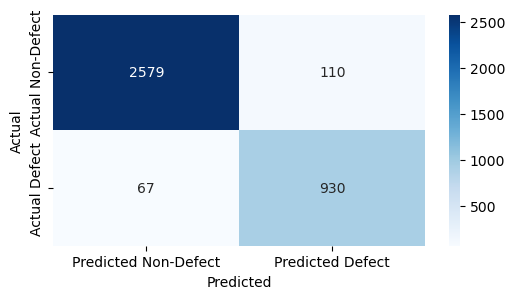

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = metrics.confusion_matrix(y_test, Prediction)

plt.figure(figsize=(6,3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Non-Defect", "Predicted Defect"],
    yticklabels=["Actual Non-Defect", "Actual Defect"]
)

#plt.title("Confusion Matrix – Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## Testing Logistic Regression model accuracy across 10 iterations - Cross Fold Model Validation

In [140]:
# Running 10-Fold Cross validation on a given algorithm
# Passing full data X and y because the K-fold will split the data and automatically choose train/test

from sklearn.model_selection import cross_val_score

Accuracy = cross_val_score(LR,X,y,cv=10,scoring='f1_weighted')

print("Accuracy of the model across 10-cross validation is : ", np.round(Accuracy,2))
print("\nFinal overall accuracy of Logistic Regression model is : ", np.round(Accuracy.mean(),2))

Accuracy of the model across 10-cross validation is :  [0.97 0.97 0.96 0.97 0.97 0.95 0.96 0.96 0.96 0.95]

Final overall accuracy of Logistic Regression model is :  0.96


# Decision Tree

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      2672
           1       0.98      0.87      0.92      1014

    accuracy                           0.96      3686
   macro avg       0.97      0.93      0.95      3686
weighted avg       0.96      0.96      0.96      3686

[[2656   16]
 [ 134  880]]
Accuracy of the model is :  0.966


<Axes: >

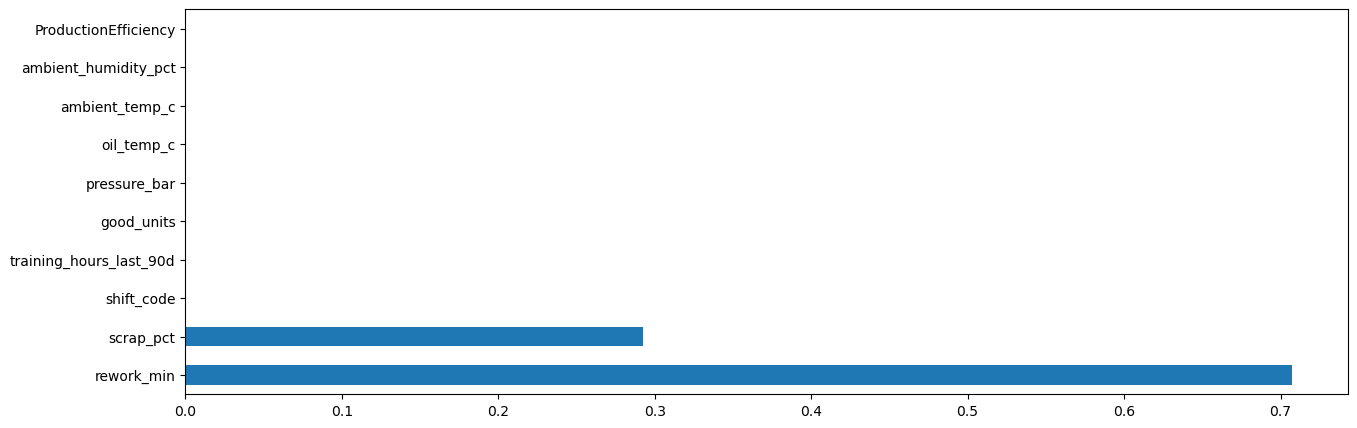

In [89]:
from sklearn.tree import DecisionTreeClassifier

# Fiting and training the model with training data and generating the predictions on testing data
DT = DecisionTreeClassifier(max_depth=3,criterion='entropy').fit(X_train,y_train)
Prediction = DT.predict(X_test)

# Measuring accuracy on Testing Data
print(metrics.classification_report(y_test,Prediction))
print(metrics.confusion_matrix(y_test,Prediction))

f1_score = metrics.f1_score(y_test,Prediction)

print("Accuracy of the model is : ", round(F1_score,3))

feature_importance = pd.Series(DT.feature_importances_,index=Predictors)
feature_importance.nlargest(10).plot(kind='barh',figsize=(15,5))

## Testing Decision Tree model accuracy across 10 iterations - Cross Fold Model Validation

In [85]:
# Running 10-Fold Cross validation on a given algorithm
# Passing full data X and y because the K-fold will split the data and automatically choose train/test

from sklearn.model_selection import cross_val_score

Accuracy = cross_val_score(DT,X,y,cv=10,scoring='f1_weighted')

print("Accuracy of the model across 10-cross validation is : ", np.round(Accuracy,2))
print("\nFinal overall accuracy of Decision Tree model is : ", np.round(Accuracy.mean(),2))

Accuracy of the model across 10-cross validation is :  [0.96 0.95 0.95 0.96 0.95 0.95 0.95 0.95 0.95 0.96]

Final overall accuracy of Decision Tree model is :  0.95


In [86]:
#Creating Testing data frame

# TestDataResult = pd.DataFrame(data=X_test,columns=Predictors)
# TestDataResult['defect_flag'] = y_test
# TestDataResult['Predicted_defect_flag']=Prediction
# TestDataResult.tail(20)

# Random Forest

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2672
           1       0.98      0.80      0.88      1014

    accuracy                           0.94      3686
   macro avg       0.95      0.90      0.92      3686
weighted avg       0.94      0.94      0.94      3686

[[2655   17]
 [ 203  811]]
Accuracy of the model is :  0.94


<Axes: >

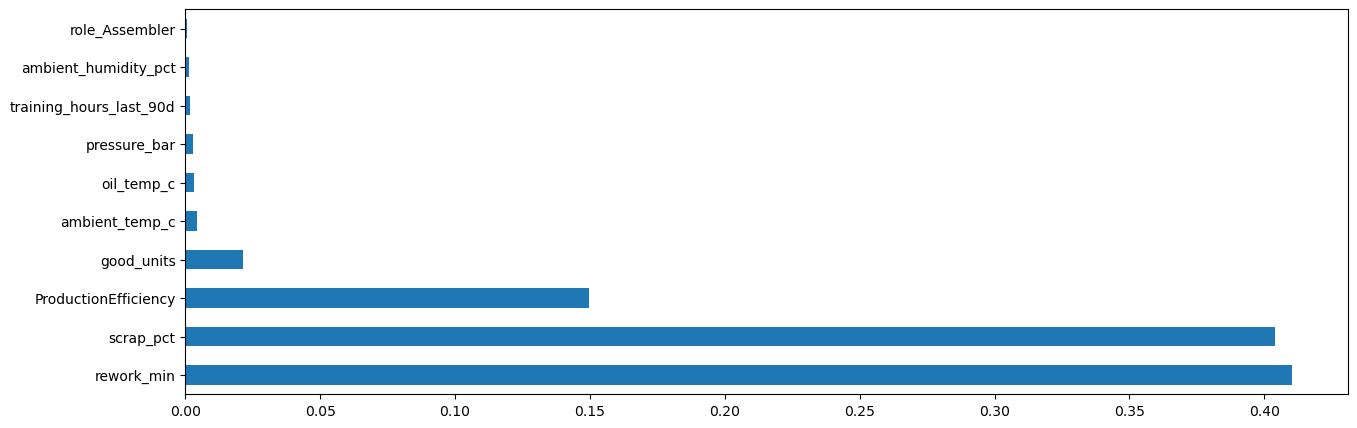

In [100]:
from sklearn.ensemble import RandomForestClassifier

# Fiting and training the model with training data and generating the predictions on testing data
RF = RandomForestClassifier(max_depth=3,n_estimators=100,criterion='gini').fit(X_train,y_train)

Prediction = RF.predict(X_test)

# Measuring accuracy on Testing Data
print(metrics.classification_report(y_test,Prediction))
print(metrics.confusion_matrix(y_test,Prediction))

f1_score = metrics.f1_score(y_test,Prediction,average='weighted')

print("Accuracy of the model is : ", round(f1_score,2))

feature_importance = pd.Series(RF.feature_importances_,index=Predictors)
feature_importance.nlargest(10).plot(kind='barh',figsize=(15,5))

## Testing Random Forest model accuracy across 10 iterations - Cross Fold Model Validation

In [101]:
# Running 10-Fold Cross validation on a given algorithm
# Passing full data X and y because the K-fold will split the data and automatically choose train/test

from sklearn.model_selection import cross_val_score

Accuracy = cross_val_score(RF,X,y,cv=10,scoring='f1_weighted')

print("Accuracy of the model across 10-cross validation is : ", np.round(Accuracy,2))
print("\nFinal overall accuracy of Random Forest model is : ", np.round(Accuracy.mean(),2))

Accuracy of the model across 10-cross validation is :  [0.94 0.95 0.94 0.94 0.93 0.94 0.93 0.95 0.95 0.94]

Final overall accuracy of Random Forest model is :  0.94


# AdaBoost

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2672
           1       0.97      0.91      0.94      1014

    accuracy                           0.97      3686
   macro avg       0.97      0.95      0.96      3686
weighted avg       0.97      0.97      0.97      3686

[[2645   27]
 [  90  924]]
Accuracy of the model is :  0.97


<Axes: >

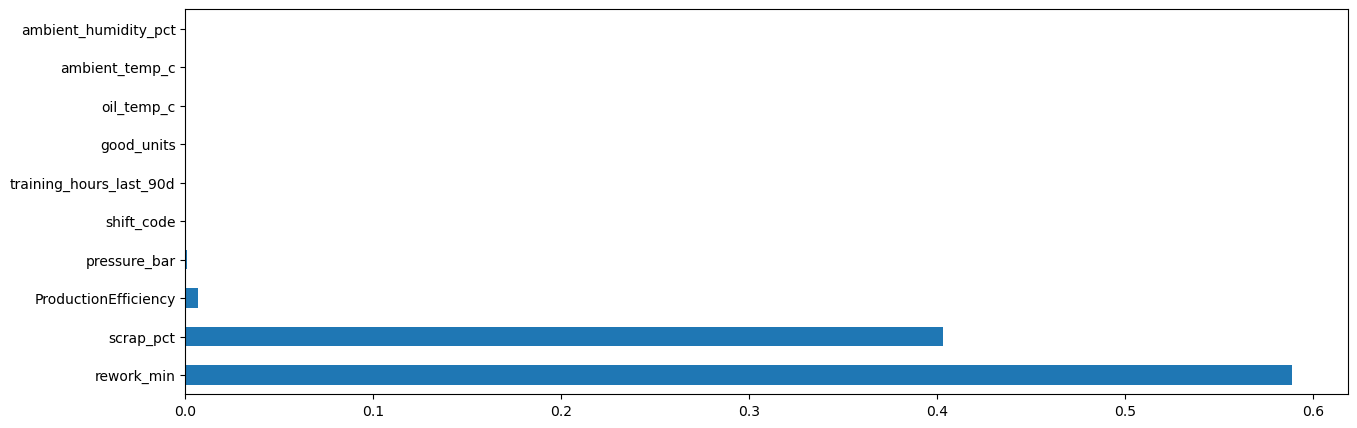

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# Fiting and training the model with training data and generating the predictions on testing data
DT = DecisionTreeClassifier(max_depth=2)
ADB = AdaBoostClassifier(estimator=DT, n_estimators=100, learning_rate=0.1).fit(X_train,y_train)

Prediction = ADB.predict(X_test)

# Measuring accuracy on Testing Data
print(metrics.classification_report(y_test,Prediction))
print(metrics.confusion_matrix(y_test,Prediction))

f1_score = metrics.f1_score(y_test,Prediction,average='weighted')

print("Accuracy of the model is : ", round(f1_score,2))

feature_importance = pd.Series(ADB.feature_importances_,index=Predictors)
feature_importance.nlargest(10).plot(kind='barh',figsize=(15,5))

## Testing AdaBoost model accuracy across 10 iterations - Cross Fold Model Validation

In [103]:
# Running 10-Fold Cross validation on a given algorithm
# Passing full data X and y because the K-fold will split the data and automatically choose train/test

from sklearn.model_selection import cross_val_score

Accuracy = cross_val_score(ADB,X,y,cv=10,scoring='f1_weighted')

print("Accuracy of the model across 10-cross validation is : ", np.round(Accuracy,2))
print("\nFinal overall accuracy of AdaBoost model model is : ", np.round(Accuracy.mean(),2))

Accuracy of the model across 10-cross validation is :  [0.97 0.96 0.96 0.97 0.97 0.96 0.96 0.97 0.96 0.96]

Final overall accuracy of AdaBoost model model is :  0.96


# XGBoost

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      2672
           1       0.95      0.91      0.93      1014

    accuracy                           0.96      3686
   macro avg       0.96      0.95      0.95      3686
weighted avg       0.96      0.96      0.96      3686

[[2628   44]
 [  91  923]]
Accuracy of the model is :  0.96


<Axes: >

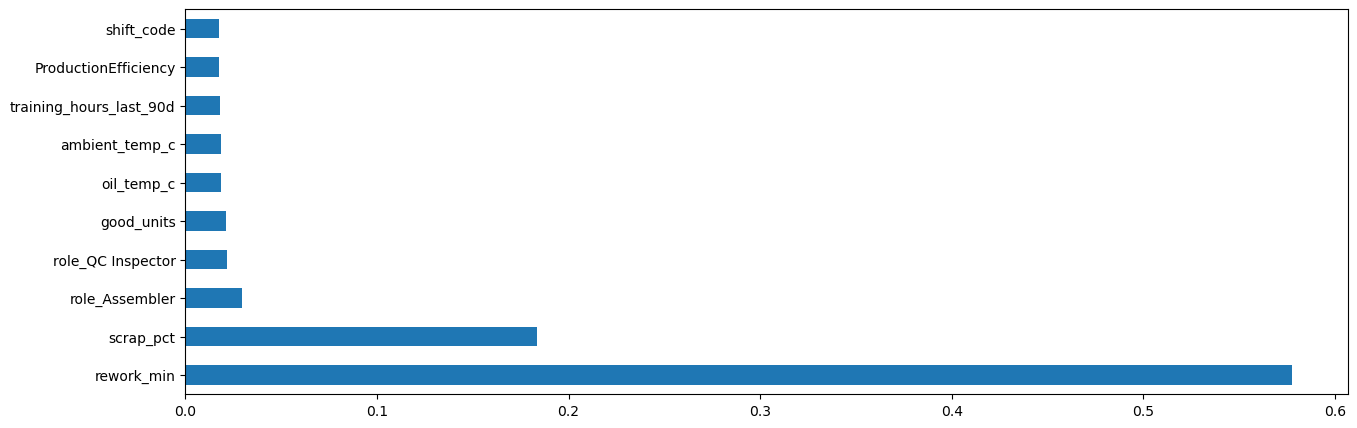

In [104]:
from xgboost import XGBClassifier

# Fiting and training the model with training data and generating the predictions on testing data
XGB = XGBClassifier(max_depth=5,n_estimators=100,learning_rate=0.1,booster="gbtree",
                    objective='binary:logistic').fit(X_train,y_train)

Prediction = XGB.predict(X_test)

# Measuring accuracy on Testing Data
print(metrics.classification_report(y_test,Prediction))
print(metrics.confusion_matrix(y_test,Prediction))

f1_score = metrics.f1_score(y_test,Prediction,average='weighted')

print("Accuracy of the model is : ", round(f1_score,2))

feature_importance = pd.Series(XGB.feature_importances_,index=Predictors)
feature_importance.nlargest(10).plot(kind='barh',figsize=(15,5))

## Testing XGBoost model accuracy across 10 iterations - Cross Fold Model Validation

In [105]:
# Running 10-Fold Cross validation on a given algorithm
# Passing full data X and y because the K-fold will split the data and automatically choose train/test

from sklearn.model_selection import cross_val_score

Accuracy = cross_val_score(XGB,X,y,cv=10,scoring='f1_weighted')

print("Accuracy of the model across 10-cross validation is : ", np.round(Accuracy,2))
print("\nFinal overall accuracy of XGBoost model model is : ", np.round(Accuracy.mean(),2))

Accuracy of the model across 10-cross validation is :  [0.96 0.97 0.96 0.97 0.97 0.95 0.96 0.96 0.96 0.96]

Final overall accuracy of XGBoost model model is :  0.96


# KNN

In [106]:
from sklearn.neighbors import KNeighborsClassifier

# Fiting and training the model with training data and generating the predictions on testing data
KNN = KNeighborsClassifier(n_neighbors=3).fit(X_train,y_train)

Prediction = KNN.predict(X_test)

# Measuring accuracy on Testing Data
print(metrics.classification_report(y_test,Prediction))
print(metrics.confusion_matrix(y_test,Prediction))

f1_score = metrics.f1_score(y_test,Prediction,average='weighted')

print("Accuracy of the model is : ", round(f1_score,2))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      2672
           1       0.93      0.81      0.86      1014

    accuracy                           0.93      3686
   macro avg       0.93      0.89      0.91      3686
weighted avg       0.93      0.93      0.93      3686

[[2608   64]
 [ 193  821]]
Accuracy of the model is :  0.93


## Testing KNN model accuracy across 10 iterations - Cross Fold Model Validation

In [107]:
# Running 10-Fold Cross validation on a given algorithm
# Passing full data X and y because the K-fold will split the data and automatically choose train/test

from sklearn.model_selection import cross_val_score

Accuracy = cross_val_score(KNN,X,y,cv=10,scoring='f1_weighted')

print("Accuracy of the model across 10-cross validation is : ", np.round(Accuracy,2))
print("\nFinal overall accuracy of KNN model model is : ", np.round(Accuracy.mean(),2))

Accuracy of the model across 10-cross validation is :  [0.94 0.93 0.94 0.93 0.93 0.93 0.93 0.94 0.93 0.93]

Final overall accuracy of KNN model model is :  0.93


### Based on the above models and accuracy, we choose *Logistic Regression*!

# Individual predictions

In [ ]:
# Selecting 10 random samples and checking the predictions

In [134]:
import numpy as np

random_idx = np.random.choice(len(X_test), 10, replace=False)

# Both are numpy arrays → use []
X_random = X_test[random_idx]
y_actual = y_test[random_idx]

# Predictions
y_pred_random = LR.predict(X_random)

# Print results
for i in range(10):
    print(f"Actual: {y_actual[i]} | Predicted: {y_pred_random[i]}")

Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
